# Genre-aware Metal Album Cover Generation (Diffusion + LoRA)

## Overview
This project explores a genre-aware system for generating metal album covers.  
We adapt a pretrained text-to-image diffusion model to metal aesthetics and evaluate outputs with multimodal metrics.

## Goals
- Build a “master” dataset linking **album cover + band + album + subgenre + lyrics**
- Generate covers in three prompt modes:
  - **G**: genre + band + album
  - **L**: lyrics summary only
  - **GL**: combined metadata + lyrics summary
- Evaluate results:
  - **CLIP text-image similarity**
  - **FID** (real vs generated)
  - Style coverage via **CLIP-embedding clustering**

## Datasets (Kaggle)
- [Large Metal Lyrics Archive (228K songs)](https://www.kaggle.com/datasets/markkorvin/large-metal-lyrics-archive-228k-songs)
- [Metal Albums Artwork](https://www.kaggle.com/datasets/benjamnmachn/metal-albums-artwork)

## Method
### 1) Data unification
- Merge CSVs by band/album names
- Remove duplicates/conflicts
- Map subgenres → broader style clusters (e.g., traditional / extreme)
- Keep only albums with reliable: cover + genre + lyrics

### 2) Prompt builder (G / L / GL)
- G: template prompt with subgenre, band, album
- L: lyrics cleaning + TF-IDF keyword extraction + short templated summary
- GL: combine metadata prompt + lyrics summary

### 3) Visual style clustering
- Extract CLIP embeddings for real covers
- k-means clustering
- Visualize with PCA/t-SNE and compare clusters vs subgenres

### 4) Diffusion generation + adaptation
- Baseline generation with pretrained model
- LoRA fine-tuning on metal cover domain (optionally separate adapters for traditional vs extreme)

### 5) Baseline for comparison
- Neural Style Transfer (content neutral images + style metal covers)

### 6) Evaluation
- CLIP cosine similarity(prompt, image)
- FID(real covers, generated covers)
- Cluster assignment distribution (real vs generated)
- LoRA training
- Evaluation: CLIP + FID + cluster coverage


## Colab-safe setup (recommended)

This notebook was **sanitized** to reduce the chance of automated policy flags on hosted notebook platforms:

- **No album-cover or generated-image rendering by default** (`SHOW_IMAGES=False`)
- **NSFW filtering** before writing images into the LoRA training folder (so your training set is safer)
- **Stable Diffusion safety checker is kept enabled** in pipeline loading

### What you need to do in Google Colab

1) Put your datasets under a folder in Google Drive (default suggested path is shown in the next cell).  
2) Run the setup cell below — it will mount Drive and create **/kaggle/input** and **/kaggle/working** symlinks to your Drive folders, so the rest of the notebook can run with minimal changes.  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip -q install --no-cache-dir \
  diffusers accelerate peft safetensors \
  "transformers<5" \
  open-clip-torch sentencepiece ftfy tqdm torchmetrics langdetect

In [ ]:
import numpy as np, scipy, sklearn, skimage
print("numpy :", np.__version__, np.__file__)
print("scipy :", scipy.__version__, scipy.__file__)
print("sklearn:", sklearn.__version__, sklearn.__file__)
print("skimage:", skimage.__version__, skimage.__file__)
print("Core stack OK")

numpy : 2.0.2 /usr/local/lib/python3.12/dist-packages/numpy/__init__.py
scipy : 1.16.3 /usr/local/lib/python3.12/dist-packages/scipy/__init__.py
sklearn: 1.6.1 /usr/local/lib/python3.12/dist-packages/sklearn/__init__.py
skimage: 0.25.2 /usr/local/lib/python3.12/dist-packages/skimage/__init__.py
Core stack OK


In [ ]:
# Core Python
import glob
import hashlib
import os, subprocess
import math
import re
import requests
import time
import json
from pathlib import Path

# Numerical and Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Images
from PIL import Image
from io import BytesIO

# Image processing (EDA)
from skimage.color import rgb2hsv
from skimage.filters import sobel
from skimage.measure import shannon_entropy

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# Utils
from tqdm.auto import tqdm

# CLIP
import open_clip

# TF-IDF
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from langdetect import detect, LangDetectException, DetectorFactory
from transformers import CLIPTokenizer, CLIPTextModel

# Diffusion model
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler

SEED = 67
WORK = Path("/content/drive/MyDrive/metal_album_cover_project/working")

In [ ]:
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

CUDA: True
GPU: Tesla T4


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Data Collection and Integration

The first step of the project focuses on collecting and integrating several external datasets that cover different aspects of the task. The following datasets are used:

- **Large Metal Lyrics Archive (228K songs)**  
  https://www.kaggle.com/datasets/markkorvin/large-metal-lyrics-archive-228k-songs/data

- **Every Metal Archives Band (November 2024)**  
  https://www.kaggle.com/datasets/guimacrlh/every-metal-archives-band-october-2024/data

- **Metal Album Art by Subgenre**  
  https://www.kaggle.com/datasets/fraserwtt/metal-album-art-by-subgenre/data

- **Metal Albums Artwork**  
  https://www.kaggle.com/datasets/benjamnmachn/metal-albums-artwork

The goal of this step is to construct a unified dataset of metal albums for which album artwork, band information, subgenre labels, and song lyrics can be reliably linked.

### Data Integration Strategy

The datasets are merged primarily based on **band name** and **album title**. Since the data originate from different sources, this process involves:

- normalization of band and album names;
- removal of duplicated or conflicting entries;
- exclusion of albums with missing or unreliable metadata.

In order to keep the experiments well controlled, the project focuses on a limited set of subgenres, namely **death metal** and **thrash metal**, for which album artwork and lyrics are sufficiently available across datasets.

### Master Dataset Construction

After cleaning and merging the data, a final *master dataset* is constructed. Each row in this dataset corresponds to a single album and contains:

- band name;
- album title;
- metal subgenre (death or thrash);
- broader style cluster (e.g. traditional vs. extreme);
- album artwork reference (local path or URL);
- aggregated lyrics text (concatenated across all songs from the album).

Albums for which any of these components are missing (artwork, genre label, or lyrics) are excluded.

Finally, the resulting dataset is split into **training** and **test** subsets, with an effort to keep the selected subgenres approximately balanced. This dataset serves as the foundation for all subsequent generation and evaluation experiments.


In [ ]:
from pathlib import Path
import glob

# Colab-native paths (stable, no hacks)
INPUT = Path("/content/drive/MyDrive/metal_album_cover_project/input")
WORK  = Path("/content/drive/MyDrive/metal_album_cover_project/working")

INPUT.mkdir(parents=True, exist_ok=True)
WORK.mkdir(parents=True, exist_ok=True)

print("INPUT =", INPUT)
print("WORK  =", WORK)

INPUT = /content/drive/MyDrive/metal_album_cover_project/input
WORK  = /content/drive/MyDrive/metal_album_cover_project/working


In [ ]:
!unzip -q "/content/drive/MyDrive/metal_album_cover_project/input/metal-albums-artwork.zip" \
  -d "/content/drive/MyDrive/metal_album_cover_project/input/metal-albums-artwork"

!unzip -q "/content/drive/MyDrive/metal_album_cover_project/input/large-metal-lyrics-archive-228k-songs.zip" \
  -d "/content/drive/MyDrive/metal_album_cover_project/input/large-metal-lyrics-archive-228k-songs"

In [ ]:
def find_first(pattern: str) -> str:
    matches = glob.glob(str(INPUT / "**" / pattern), recursive=True)
    if not matches:
        raise FileNotFoundError(f"No files match: {pattern}")
    return matches[0]

artwork_csv = find_first("metal_albums_artwork_images.csv")
lyrics_csv  = find_first("metal_lyrics.csv")

print("artwork:", artwork_csv)
print("lyrics:", lyrics_csv)

artwork: /content/drive/MyDrive/metal_album_cover_project/input/metal-albums-artwork/metal_albums_artwork_images.csv
lyrics: /content/drive/MyDrive/metal_album_cover_project/input/large-metal-lyrics-archive-228k-songs/metal_lyrics.csv


In [ ]:
pd.set_option("display.max_colwidth", 120)

df_art = pd.read_csv(artwork_csv)
df_lyrics = pd.read_csv(lyrics_csv)

In [ ]:
print("art:", df_art.shape); display(df_art.head(3)); print(df_art.columns)
print("lyrics:", df_lyrics.shape); display(df_lyrics.head(3)); print(df_lyrics.columns)

art: (16728, 8)


,artist_name,artist_country,artist_status,artist_main_genre,artist_alt_genre,album_name,album_cover_url,album_cover_image
0,'68,NaN,NaN,NaN,NaN,In Humor and Sadness,https://is4-ssl.mzstatic.com/image/thumb/Music/v4/e1/5d/51/e15d51d2-e8b7-9862-0752-4d9763514f90/source/512x512.jpg,/9j/4AAQSkZJRgABAQAASABIAAD/4QBqRXhpZgAATU0AKgAAAAgAAYdpAAQAAAABAAAAGgAAAAAABJKGAAcAAAARAAAAUKABAAMAAAABAAEAAKACAAQA...
1,(Sic)Monic,NaN,NaN,NaN,NaN,Somnambulist,https://is1-ssl.mzstatic.com/image/thumb/Music/v4/77/dc/22/77dc2282-2fd1-87fc-0216-237de4e1d715/source/512x512.jpg,/9j/4AAQSkZJRgABAQAASABIAAD/4QBqRXhpZgAATU0AKgAAAAgAAYdpAAQAAAABAAAAGgAAAAAABJKGAAcAAAARAAAAUKABAAMAAAABAAEAAKACAAQA...
2,+\,NaN,NaN,NaN,NaN,Emerald Island,https://is1-ssl.mzstatic.com/image/thumb/Music30/v4/af/74/68/af746803-ac4e-ac37-d95a-51dd67959b3f/source/512x512.jpg,/9j/4AAQSkZJRgABAQAASABIAAD/4QBqRXhpZgAATU0AKgAAAAgAAYdpAAQAAAABAAAAGgAAAAAABJKGAAcAAAARAAAAUKABAAMAAAABAAEAAKACAAQA...


Index(['artist_name', 'artist_country', 'artist_status', 'artist_main_genre',
       'artist_alt_genre', 'album_name', 'album_cover_url',
       'album_cover_image'],
      dtype='object')
lyrics: (228288, 6)


,Artist,Album,Song,Lyric,SongNum,Year
0,...AAAARRGHH,aaaarrghh,_Gecenin_G__lgesi,Kara bulutlar sardГ„В± yine dГѓВјnyamГ„В±\nKГ„В±Г…Вџ yerleГ…Вџti ruhuma\nGГѓВјneГ…Вџ asГ„В±lГ„В±ysa da gГѓВ¶kyГѓВјzГ...,1,0
1,...AAAARRGHH,aaaarrghh,_Son___afak,Dolunay parlak gГѓВ¶rГѓВјnmГѓВјyor bu gece\nBenim toprak dolu kГѓВ¶r gГѓВ¶zlerime\nSon Г…ВџafaГ„ВџГ„В±n sГѓВ¶kmesini...,2,0
2,...AAAARRGHH,aaaarrghh,_F__rt__na_Yakla__yyor...,Ay Г„В±Г…ВџГ„В±Г„ВџГ„В±nГ„В±n altГ„В±nda\nYalnГ„В±z bir ruh dolaГ…ВџГ„В±r\nSoГ„Вџuk ormanlarda\nHГ„В±Г…ВџГ„В±rdayan ...,3,0


Index(['Artist', 'Album', 'Song', 'Lyric', 'SongNum', 'Year'], dtype='object')


## Data Merging: Lyrics and Album Artwork

This step combines two publicly available datasets in order to create an album-level dataset that links textual and visual information:

- **Large Metal Lyrics Archive (228K songs)**  
  https://www.kaggle.com/datasets/markkorvin/large-metal-lyrics-archive-228k-songs/data

- **Metal Albums Artwork**  
  https://www.kaggle.com/datasets/benjamnmachn/metal-albums-artwork/data?select=metal_albums_artwork_images.csv

### Goal

The objective is to obtain a dataset of metal albums for which both **song lyrics**, **album metadata** and **album artwork references** are available. This dataset will later be used for prompt construction, image generation, and evaluation.

### Merging Strategy

1. Both datasets were loaded and cleaned by removing entries with missing band names, album titles, or lyrics.
2. Band and album names were normalized (lowercasing, punctuation removal, whitespace normalization) to reduce mismatches between sources.
3. A key was constructed by concatenating the normalized band name and album title.
4. The lyrics dataset was aggregated to album level by concatenating all song lyrics belonging to the same album.
5. An inner join was performed between the album artwork dataset and the aggregated lyrics dataset using the key.

### Result

The resulting dataset contains one row per album and includes:
- band name
- album title
- metal subgenre label
- album artwork URL
- aggregated lyrics text
- number of songs per album
- total lyrics length

Albums missing either lyrics or artwork information were excluded from the final dataset.

In [ ]:
def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower().strip()
    x = x.replace("&", "and")
    x = re.sub(r"[\.\,\!\?\:\;\(\)\[\]\{\}\'\"\`]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

# Create a unique album key, for example: metallica||master of puppets
# We will join 'Metal Albums Artwork' and 'Large Metal Lyrics Archive (228K songs)', so
# we will join on this
def make_key(band, album):
    return normalize_text(band) + "||" + normalize_text(album)

In [ ]:
# Work with the Metal Albums Artwork dataset

ART_BAND_COL  = "artist_name"
ART_ALBUM_COL = "album_name"
ART_GENRE_COL = "artist_main_genre"
ART_URL_COL   = "image_url"

# Remove records that don't contain an album name, artist name or genre
tmp = df_art.dropna(subset=[ART_BAND_COL, ART_ALBUM_COL, ART_GENRE_COL]).copy()

# Make genres lowercase so that we can search in them easier
tmp["genre_norm"] = tmp[ART_GENRE_COL].astype(str).str.lower()

# Mapping to target genres, only death and thrash (united with speed metal) are kept,
# the rest is thrown away
def map_to_target_genre(g):
    if "death" in g:
        return "death"
    if "thrash" in g or "speed metal" in g:
        return "thrash"
    return None

# Only death and thrash metal albums are kept
tmp["target_genre"] = tmp["genre_norm"].map(map_to_target_genre)
tmp = tmp.dropna(subset=["target_genre"])

# For each row, normalize and create a key like this: metallica||master of puppets
tmp["key"] = tmp.apply(lambda r: make_key(r[ART_BAND_COL], r[ART_ALBUM_COL]), axis=1)

# Save url, but don't download images yet
# Rename columns
tmp_renamed = tmp.rename(columns={
    ART_BAND_COL: "band",
    ART_ALBUM_COL: "album",
    ART_URL_COL: "album_cover_url"
})

# Choose needed columns
artwork_candidates = (
    tmp_renamed[
        ["key", "band", "album", "target_genre", "album_cover_url"]
    ]
    .drop_duplicates("key")
)

artwork_candidates["target_genre"].value_counts(), artwork_candidates.shape


(target_genre
 death     3221
 thrash    1241
 Name: count, dtype: int64,
 (4462, 5))

In [ ]:
# working with the lyrics dataset

LYR_BAND_COL  = "Artist"
LYR_ALBUM_COL = "Album"
LYR_TEXT_COL  = "Lyric"

MIN_LYRICS_LENGTH = 500

# Cleanup - remove sonts that don't include an artist name, album or lyrics
ly = df_lyrics.dropna(subset=[LYR_BAND_COL, LYR_ALBUM_COL, LYR_TEXT_COL]).copy()

# Key for merging (again)
ly["key"] = ly.apply(lambda r: make_key(r[LYR_BAND_COL], r[LYR_ALBUM_COL]), axis=1)

# Group by album, key = normalized band||album
album_groups = ly.groupby("key", as_index=False)

# Aggregate for each album
album_lyrics = album_groups.agg(
    band=(LYR_BAND_COL, "first"), # get first occurrence of Artist
    album=(LYR_ALBUM_COL, "first"), # get first occurrence of Album
    n_songs=(LYR_TEXT_COL, "count"), # count number of songs (number of rows)
    lyrics_full=(LYR_TEXT_COL, lambda s: "\n".join(s.astype(str))) # concat lyrics
)

# Remove albums that contain too little lyrics (uninformative for the NLP part)
album_lyrics["lyrics_len"] = album_lyrics["lyrics_full"].astype(str).str.len()
album_lyrics = album_lyrics[album_lyrics["lyrics_len"] >= MIN_LYRICS_LENGTH]

album_lyrics.shape

(24768, 6)

In [ ]:
master_text = artwork_candidates.merge(
    album_lyrics[["key","lyrics_full","n_songs","lyrics_len"]],
    on="key",
    how="inner"
)

print(master_text.shape)
master_text["target_genre"].value_counts()


(3159, 8)


,count
target_genre,
death,2326
thrash,833


In [ ]:
master_text = master_text.sample(frac=1, random_state=42).reset_index(drop=True)

min_n = master_text["target_genre"].value_counts().min()

balanced = (
    master_text.sample(frac=1, random_state=42)
              .groupby("target_genre", group_keys=False)
              .head(min_n)
              .reset_index(drop=True)
)

print(balanced["target_genre"].value_counts())

target_genre
thrash    833
death     833
Name: count, dtype: int64


In [ ]:
out_path = WORK / "master_death_thrash.parquet"
balanced.to_parquet(out_path, index=False)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/metal_album_cover_project/working/master_death_thrash.parquet


In [ ]:
df = pd.read_parquet(WORK / "master_death_thrash.parquet")

print(df.shape)
df.head()

(1666, 8)


,key,band,album,target_genre,album_cover_url,lyrics_full,n_songs,lyrics_len
0,bulldozer||the day of wrath,Bulldozer,The Day of Wrath,thrash,https://is3-ssl.mzstatic.com/image/thumb/Music...,[Instrumental]\n\n\nOne life here\nOne soul th...,9,4744
1,before the dawn||soundscape of silence,Before The Dawn,Soundscape of Silence,death,https://is2-ssl.mzstatic.com/image/thumb/Music...,By the powers vested in me\nBy the entity of c...,10,4912
2,diabolic||infinity through purification,Diabolic,Infinity Through Purification,death,https://is2-ssl.mzstatic.com/image/thumb/Music...,[Hersemann/Malone]\n\nAll our futures once wer...,8,7943
3,nocturnal rites||new world messiah,Nocturnal Rites,New World Messiah,death,https://is2-ssl.mzstatic.com/image/thumb/Music...,"Alone in a world of silence, I'm crawling in y...",12,7140
4,pentagram chile||the malefice,Pentagram Chile,The Malefice,thrash,https://is1-ssl.mzstatic.com/image/thumb/Music...,"Eternal foe, antagonist\nopposite poles mutual...",17,9681


## Downloading Album Artwork Images

After constructing the master dataset, the next step is to download the actual album artwork images using the URLs provided in the dataset.

### Procedure

1. A local directory is created to store downloaded album covers.
2. Each album artwork URL is converted into a unique filename using a hash function.
3. Images are downloaded via HTTP requests and stored locally.
4. Failed downloads (e.g., broken links or timeouts) are skipped to allow the process to continue.

### Outcome

This step produces a local collection of album artwork images that can be used for:
- visual inspection and sanity checking
- image embedding extraction
- clustering and style analysis
- conditioning inputs for generative image models

In [ ]:
df.columns

Index(['key', 'band', 'album', 'target_genre', 'album_cover_url',
       'lyrics_full', 'n_songs', 'lyrics_len'],
      dtype='object')

In [ ]:
# Quick sanity check just to make sure that the links lead to anywhere
df["album_cover_url"].head(5).tolist()

['https://is3-ssl.mzstatic.com/image/thumb/Music114/v4/ed/ee/28/edee2874-0fd4-edc4-c3af-228b782ca740/source/512x512.jpg',
 'https://is2-ssl.mzstatic.com/image/thumb/Music111/v4/de/75/7a/de757a4d-102d-6886-61c4-099ea974eb53/source/512x512.jpg',
 'https://is2-ssl.mzstatic.com/image/thumb/Music/v4/40/2f/1a/402f1aaa-f18e-1cc5-9ad0-4b7011397e1e/source/512x512.jpg',
 'https://is2-ssl.mzstatic.com/image/thumb/Music6/v4/53/8e/84/538e8479-a333-ae50-86e9-76fa4cd05ce3/source/512x512.jpg',
 'https://is1-ssl.mzstatic.com/image/thumb/Music4/v4/b4/e1/2a/b4e12aa3-b509-aca8-d2a0-0bba3ffadad9/source/512x512.jpg']

In [ ]:
urls = df.sample(5, random_state=0)["album_cover_url"]

for url in urls:
    try:
        r = requests.head(url, timeout=10)
        print(r.status_code, url)
    except Exception as e:
        print("FAILED:", url)

200 https://is2-ssl.mzstatic.com/image/thumb/Music62/v4/c2/d7/bb/c2d7bb0f-0467-68b2-cc99-65de36c5bc88/source/512x512.jpg
200 https://is3-ssl.mzstatic.com/image/thumb/Music/v4/ed/a1/01/eda1016e-fba9-c9cc-8e26-c51da775c90d/source/512x512.jpg
200 https://is1-ssl.mzstatic.com/image/thumb/Music/v4/04/b0/0b/04b00b55-d235-6ef3-76f0-30afd19442ac/source/512x512.jpg
200 https://is3-ssl.mzstatic.com/image/thumb/Music71/v4/b6/c2/9f/b6c29f3c-304e-2b7d-442c-6062bb226381/source/512x512.jpg
200 https://is2-ssl.mzstatic.com/image/thumb/Music69/v4/1e/61/55/1e615509-6036-dc4e-be08-fd1a5c1392ad/source/512x512.jpg


In [ ]:
# NOTE: Album cover previews are disabled by default for platform-safety.
# Set SHOW_IMAGES=True only if you have filtered data and understand the platform policies.
if globals().get("SHOW_IMAGES", False):
    url = df.sample(1)["album_cover_url"].iloc[0]
    img = Image.open(BytesIO(requests.get(url).content))
    img
else:
    print("SHOW_IMAGES=False; skipping random album-cover preview.")

SHOW_IMAGES=False; skipping random album-cover preview.


In [ ]:
covers_dir = Path("/kaggle/working/covers_preview")
covers_dir.mkdir(parents=True, exist_ok=True)

def url_to_name(url: str) -> str:
    return hashlib.md5(url.encode("utf-8")).hexdigest() + ".jpg"

def download_one(url: str, out_path: Path, timeout=20) -> bool:
    if out_path.exists() and out_path.stat().st_size > 0:
        return True
    try:
        r = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"}, stream=True)
        if r.status_code != 200:
            return False
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(out_path, format="JPEG", quality=95)
        return True
    except Exception:
        return False

sample = df.sample(12, random_state=0).copy()
paths = []

for url in sample["album_cover_url"]:
    p = covers_dir / url_to_name(url)
    ok = download_one(url, p)
    paths.append(str(p) if ok else None)

sample["cover_path"] = paths
sample[["band", "album", "target_genre", "cover_path"]]


,band,album,target_genre,cover_path
1109,Allegaeon,Proponent for Sentience,death,/kaggle/working/covers_preview/05993d193caf0b3ac6d327c7c0ce72be.jpg
342,Adelaide,Pergamum,death,/kaggle/working/covers_preview/6e6cc2a61c89b0aa53aeb4613df86507.jpg
381,Cadaverous Condition,To the Night Sky,death,/kaggle/working/covers_preview/79eee1f04a36f9de4cc27a43451f8399.jpg
511,Deadsquad,Tyranation,death,/kaggle/working/covers_preview/503760b13c499951d6cf93755537b407.jpg
1605,Holocaust,The Courage to Be,thrash,/kaggle/working/covers_preview/8e385b50473b9d587854ffe189cbc577.jpg
853,Antestor,Martyrium,death,/kaggle/working/covers_preview/338ce3a1f6a8ef9cd6524ae10052ff5d.jpg
685,Send More Paramedics,The Awakening,thrash,/kaggle/working/covers_preview/b3f3e6d3be5a029b380e9f551a63a705.jpg
425,Gardenian,Two Feet Stand,death,/kaggle/working/covers_preview/560de187139edebb6c7b6143f0d43c01.jpg
539,Scar Symmetry,Pitch Black Progress,death,/kaggle/working/covers_preview/13db26928ed69fbf2409701790f47e8e.jpg
557,Cronos,Dancing in the Fire,death,/kaggle/working/covers_preview/0ede4959d827b76676231ab1959fde56.jpg


In [ ]:
# NOTE: Album cover previews are disabled by default for platform-safety.
if globals().get("SHOW_IMAGES", False):
    to_show = sample.dropna(subset=["cover_path"]).head(6)

    fig, axes = plt.subplots(1, len(to_show), figsize=(3*len(to_show), 4))
    if len(to_show) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, to_show.iterrows()):
        ax.imshow(Image.open(row["cover_path"]))
        ax.set_title(
            f"{row['band']}\n{row['album']}\n({row['target_genre']})",
            fontsize=9
        )
        ax.axis("off")

    plt.show()
else:
    print("SHOW_IMAGES=False; skipping cover preview grid.")


SHOW_IMAGES=False; skipping cover preview grid.


In [ ]:
covers_dir = Path("/kaggle/working/covers")
covers_dir.mkdir(parents=True, exist_ok=True)

cover_paths = []
ok_flags = []

for url in tqdm(df["album_cover_url"].astype(str).tolist()):
    out_path = covers_dir / url_to_name(url)
    ok = download_one(url, out_path)
    ok_flags.append(ok)
    cover_paths.append(str(out_path) if ok else None)
    time.sleep(0.03)  # small throttle to be polite / reduce bans

df = df.copy()
df["cover_path"] = cover_paths
df["download_ok"] = ok_flags

print("Download success rate:", df["download_ok"].mean())
df["download_ok"].value_counts()

  0%|          | 0/1666 [00:00<?, ?it/s]

Download success rate: 0.9993997599039616


,count
download_ok,
True,1665
False,1


In [ ]:
df_ok = df[df["download_ok"]].copy()
print(df_ok.shape)

(1665, 10)


In [ ]:
out_path = WORK / "master_death_thrash_with_covers.parquet"
df.to_parquet(out_path, index=False)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/metal_album_cover_project/working/master_death_thrash_with_covers.parquet


In [ ]:
covers_dir = WORK / "covers"
covers_dir.mkdir(parents=True, exist_ok=True)

df.to_parquet(covers_dir / "metadata.parquet", index=False)
!ls -lh /content/drive/MyDrive/metal_album_cover_project/working/covers | head -n 20

total 199M
-rw------- 1 root root 162K Feb  2 02:27 0016e645b1eb67147e9ec71f1f229190.jpg
-rw------- 1 root root 109K Feb  2 02:27 002fbe203df94ca6030f3b956ee72db2.jpg
-rw------- 1 root root 127K Feb  2 02:24 00655ab37b633c6da6e84342ee906bbc.jpg
-rw------- 1 root root 152K Feb  2 02:32 00b356c5216e6b7d5de39a094dfd736a.jpg
-rw------- 1 root root 155K Feb  2 02:31 00d5286752f074a87951a363807903fa.jpg
-rw------- 1 root root 167K Feb  2 02:33 00eb3d191ba0c4e0b4a9d304792fa3ce.jpg
-rw------- 1 root root 109K Feb  2 02:33 00fb1becf140319b6ba773e0cbade2a0.jpg
-rw------- 1 root root  63K Feb  2 02:31 012b9c6a55c03201f11cd2a45b9692fb.jpg
-rw------- 1 root root 138K Feb  2 02:31 0155d53e12c1d2f305b205375fd8fc74.jpg
-rw------- 1 root root 148K Feb  2 02:31 017d9f2270b2a358be4ffc9921df02db.jpg
-rw------- 1 root root 111K Feb  2 02:30 01b1540190ad8ff0278f6a63303ff9ca.jpg
-rw------- 1 root root  86K Feb  2 02:25 021262c8134bff7d49b5d3df70290641.jpg
-rw------- 1 root root 141K Feb  2 02:29 025a567b72b6

## Load the datasets again

In [ ]:
df = pd.read_parquet(WORK / "master_death_thrash_with_covers.parquet")

print(df.shape)
df.head()

In [ ]:
df["cover_path"] = df["cover_path"].apply(
    lambda p: str(COVERS_DIR / Path(p).name)
)

## Exploratory Data Analysis (EDA)

Before moving to prompt construction (G / L / GL), CLIP-based evaluation, and diffusion-based generation, we perform **Exploratory Data Analysis (EDA)** on the final merged dataset.

The goal of this EDA is to:
- validate that the merged dataset is consistent and usable
- understand the distribution of the main variables (genres, lyrics length, number of songs)
- verify that album cover downloads were successful
- identify potential data quality issues

### Dataset Overview
Basic statistics and counts

In [ ]:
print("Shape:", df.shape)
display(df.head(3))

# Basic info about dtypes and missing values footprint
df.info()

Shape: (1666, 10)


,key,band,album,target_genre,album_cover_url,lyrics_full,n_songs,lyrics_len,cover_path,download_ok
0,bulldozer||the day of wrath,Bulldozer,The Day of Wrath,thrash,https://is3-ssl.mzstatic.com/image/thumb/Music114/v4/ed/ee/28/edee2874-0fd4-edc4-c3af-228b782ca740/source/512x512.jpg,[Instrumental]\n\n\nOne life here\nOne soul there\nI'm bored with living\nI don't even care\nSuck up their brain\nRi...,9,4744,/kaggle/working/covers/390366afb6080f0aeaab02d58a1edb25.jpg,True
1,before the dawn||soundscape of silence,Before The Dawn,Soundscape of Silence,death,https://is2-ssl.mzstatic.com/image/thumb/Music111/v4/de/75/7a/de757a4d-102d-6886-61c4-099ea974eb53/source/512x512.jpg,By the powers vested in me\nBy the entity of choice\nI pronounce myself dead\nAt 4:18 am\nI am gathered here\nTo rem...,10,4912,/kaggle/working/covers/d3d3bfb8ab6369c7c9136fc3a0dee2bb.jpg,True
2,diabolic||infinity through purification,Diabolic,Infinity Through Purification,death,https://is2-ssl.mzstatic.com/image/thumb/Music/v4/40/2f/1a/402f1aaa-f18e-1cc5-9ad0-4b7011397e1e/source/512x512.jpg,[Hersemann/Malone]\n\nAll our futures once were foretold\nFirst etched stone now carved flesh\nDespite our frail hum...,8,7943,/kaggle/working/covers/4a39a5877b74061d6c616bba11980905.jpg,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   key              1666 non-null   object
 1   band             1666 non-null   object
 2   album            1666 non-null   object
 3   target_genre     1666 non-null   object
 4   album_cover_url  1666 non-null   object
 5   lyrics_full      1666 non-null   object
 6   n_songs          1666 non-null   int64 
 7   lyrics_len       1666 non-null   int64 
 8   cover_path       1665 non-null   object
 9   download_ok      1666 non-null   bool  
dtypes: bool(1), int64(2), object(7)
memory usage: 118.9+ KB


In [ ]:
cols_core = ["key","band","album","target_genre","album_cover_url","lyrics_full","n_songs","lyrics_len","cover_path","download_ok"]
df[cols_core].isna().sum().sort_values(ascending=False)

,0
cover_path,1
key,0
band,0
album,0
album_cover_url,0
target_genre,0
lyrics_full,0
n_songs,0
lyrics_len,0
download_ok,0


In [ ]:
df["target_genre"].value_counts()

,count
target_genre,
thrash,833
death,833


In [ ]:
summary = (
    df.groupby("target_genre")
      .agg(
          albums_count=("key", "count"),
          avg_lyrics_length=("lyrics_len", "mean"),
          median_lyrics_length=("lyrics_len", "median"),
          lyrics_length_q25=("lyrics_len", lambda s: s.quantile(0.25)),
          lyrics_length_q75=("lyrics_len", lambda s: s.quantile(0.75)),
          avg_tracks_per_album=("n_songs", "mean"),
          median_tracks_per_album=("n_songs", "median"),
          min_tracks_per_album=("n_songs", "min"),
          max_tracks_per_album=("n_songs", "max"),
      )
      .round(1)
)

summary

,albums_count,avg_lyrics_length,median_lyrics_length,lyrics_length_q25,lyrics_length_q75,avg_tracks_per_album,median_tracks_per_album,min_tracks_per_album,max_tracks_per_album
target_genre,,,,,,,,,
death,833,8373.1,7961.0,5874.0,10333.0,10.1,10.0,2,23
thrash,833,8741.8,8384.0,6524.0,10486.0,10.4,10.0,1,25


### Basic Statistics Overview

The final dataset contains **1,666 metal albums** - **833 death** and **832 thrash**. Each entry includes album metadata, full lyrics, track count, and a corresponding album cover (with only one missing image file).

Both genres show **very similar structural properties**:
- The **median number of tracks per album** is 10 for both death and thrash
- The **distribution of track counts** is comparable, with a small number of outliers (EPs and large compilations)
- **Lyrics length** is slightly higher on average for thrash albums, but the interquartile ranges significantly overlap, which indicates no strong genre separation based on textual length alone

### Textual Characteristics

To better understand structural differences between the two genres, we analyze
the distribution of lyrics length and the number of tracks per album.

{'whiskers': [<matplotlib.lines.Line2D at 0x7e5576bfbe30>,
 'caps': [<matplotlib.lines.Line2D at 0x7e5576686630>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e55947c3890>,
 'medians': [<matplotlib.lines.Line2D at 0x7e5576686bd0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7e5576686ea0>,
 'means': []}

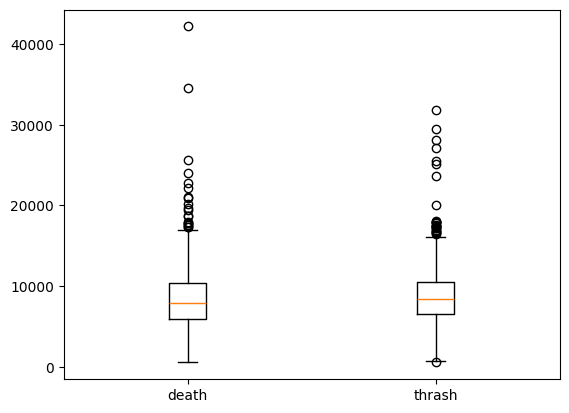

In [ ]:
plt.boxplot(
    [df.loc[df["target_genre"]=="death","lyrics_len"],
     df.loc[df["target_genre"]=="thrash","lyrics_len"]],
    tick_labels=["death","thrash"]
)

{'whiskers': [<matplotlib.lines.Line2D at 0x7e55766e1040>,
 'caps': [<matplotlib.lines.Line2D at 0x7e55766e1490>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e55766e0d70>,
 'medians': [<matplotlib.lines.Line2D at 0x7e55766e1a30>,
 'fliers': [<matplotlib.lines.Line2D at 0x7e55766e1d00>,
 'means': []}

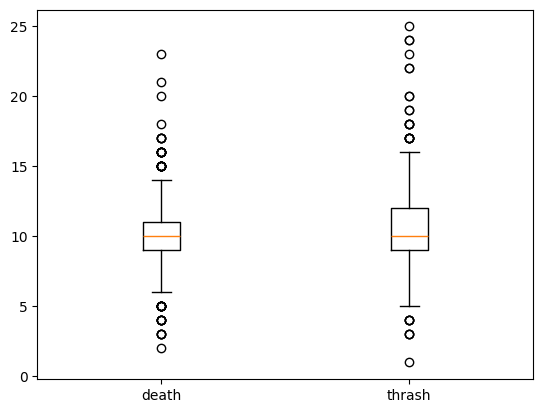

In [ ]:
plt.boxplot(
    [df.loc[df["target_genre"]=="death","n_songs"],
     df.loc[df["target_genre"]=="thrash","n_songs"]],
    tick_labels=["death","thrash"]
)

Both boxplots show a strong overlap between death and thrash metal albums.
The median values and interquartile ranges are nearly identical, suggesting
that basic structural properties such as album length and track count do not
provide a strong genre-discriminative signal.

Let's see the outliers - below are the top 10 albums with the shortest lyrics and least number of songs.

In [ ]:
# shortest lyrics
df.sort_values("lyrics_len").head(10)[["band","album","target_genre","n_songs","lyrics_len"]]

,band,album,target_genre,n_songs,lyrics_len
212,Ramming Speed,"Doomed to Destroy, Destined to Die",thrash,13,544
100,Acranius,Dishonor,death,10,624
982,Bywar,Twelve Devil's Graveyards,thrash,12,736
336,Acranius,Reign of Terror,death,10,767
313,All Out War,Give Us Extinction,thrash,12,788
588,Convulse,Cycle of Revenge,death,8,794
1063,Night In Gales,The Last Sunsets,death,12,854
70,Necronomicon,The Return of the Witch,thrash,9,875
72,Prostitute Disfigurement,Deeds of Derangement,death,11,974
652,Quorthon,Album,death,10,1043


In [ ]:
# albums with very few songs
df.sort_values("n_songs").head(10)[["band","album","target_genre","n_songs","lyrics_len"]]

,band,album,target_genre,n_songs,lyrics_len
281,Impiety,Worshippers of the Seventh Tyranny,thrash,1,2552
703,Edge Of Sanity,Crimson,death,2,12967
328,Grey Skies Fallen,Introspective,death,3,4644
317,Novembers Doom,For Every Leaf That Falls,death,3,2261
1084,Nox,Zazaz,thrash,3,3243
216,God,Sufletul Neamului,death,3,3444
1195,Votum,Metafiction,thrash,3,2939
994,Children Of Bodom,In Your Face,death,3,5040
1212,Grave Digger,Shoot Her Down,thrash,3,1831
472,Bolt Thrower,Spearhead,death,4,3060


In [ ]:
# should be 1 row per album key
# No duplicates
df["key"].duplicated().mean(), df["key"].duplicated().sum()

(np.float64(0.0), np.int64(0))

In [ ]:
# duplicated cover URLs (same cover used multiple times)
# There are 18 instances of URLs being used multiple times - perhaps a mistake or just reissues/remasters of the same album that use the cover
df["album_cover_url"].duplicated().sum()

np.int64(15)

In [ ]:
df["download_ok"].value_counts(dropna=False)
print("Success rate:", df["download_ok"].mean())

Success rate: 0.9993997599039616


In [ ]:
# check existence for a sample (fast)
sample_paths = df["cover_path"].dropna().sample(200, random_state=0)
exists_rate = sample_paths.map(lambda p: Path(p).exists()).mean()
print("Cover file exists rate (sample=200):", exists_rate)

Cover file exists rate (sample=200): 1.0


In [ ]:
# Sample 3 albums randomly
df.sample(3, random_state=42)[["band","album","target_genre","n_songs","lyrics_len"]]

,band,album,target_genre,n_songs,lyrics_len
940,Silent Civilian,Rebirth of the Temple,death,13,10333
986,Deuteronomium,Street Corner Queen,death,16,13696
405,Conducting From The Grave,When Legends Become Dust,death,10,10430


In [ ]:
# preview lyrics snippets
df.sample(3, random_state=42)["lyrics_full"].str.slice(0, 400)

,lyrics_full
940,"[Instrumental]\n\n\nFace The Mirror, See the Liar, Fucking Traitor\nConversations in the darkness, Instigator\nTrust..."
986,"In the evening she stands in the corner of street\nEvery single night, she is a street corner queen\nWith so many li..."
405,Clear your throat 'cause i can't understand a fucking word you say.\nYou're running out of prescriptions to hide beh...


In [ ]:
# Unsuccessful download
df["download_ok"].value_counts(dropna=False)
df[df["download_ok"] == False][["band","album","album_cover_url","cover_path"]]
df[df["cover_path"].isna()][["band","album","album_cover_url","download_ok"]]

,band,album,album_cover_url,download_ok
257,Phobia,Unrelenting,https://is3-ssl.mzstatic.com/image/thumb/Music/v4/cf/a5/fd/cfa5fd30-fefe-185a-9a54-a46665c4c088/source/512x512.jpg,False


### Image Feature Extraction (EDA)

To perform quantitative EDA on album covers, we first filter the dataset to keep only entries with a valid local image file. We then draw a fixed-size random sample of 500 covers and extract a set handcrafted visual descriptors from each image.

#### 1) Filter to valid local cover files and create a sample
#### 2) Handcrafted feature extraction per cover
For each cover image - convert to RGB, resize to 256×256. We then compute:

- **Brightness (mean luminance)**: perceived brightness using a standard weighted RGB luminance formula
- **Contrast proxy (luminance std)**: standard deviation of luminance values (higher ≈ more contrast)
- **Saturation (HSV S mean)**: average color saturation after converting the image to HSV
- **Dark pixel ratio**: fraction of pixels with luminance below a threshold (here `< 0.15`), measuring how "dark" the cover is
- **Edge density**: proportion of pixels with strong edges using the Sobel operator (proxy for visual complexity/detail)
- **Entropy**: Shannon entropy of luminance values (proxy for image information content / texture variety)
- **Mean RGB channels**: average red/green/blue values (a coarse proxy for overall color tone)

#### 3) Build a feature table for analysis
We apply feature extraction to each sampled cover and store the results in a DataFrame`img_feats` - used for comparisons across genres (boxplots, distributions) and simple baseline classification experiments.

In [ ]:
df_img = df[df["cover_path"].notna()].copy()
df_img["cover_exists"] = df_img["cover_path"].map(lambda p: Path(p).exists())
df_img = df_img[df_img["cover_exists"]]

sample = df_img.sample(500, random_state=0)
sample.shape

(500, 11)

In [ ]:
def extract_image_features(path):
    img = Image.open(path).convert("RGB").resize((256, 256))
    arr = np.asarray(img) / 255.0  # [0,1]

    # brightness (perceived luminance)
    luminance = 0.2126*arr[:,:,0] + 0.7152*arr[:,:,1] + 0.0722*arr[:,:,2]
    brightness_mean = float(luminance.mean())
    brightness_std  = float(luminance.std())  # proxy for contrast

    # saturation from HSV
    hsv = rgb2hsv(arr)
    saturation_mean = float(hsv[:,:,1].mean())

    # "dark pixels" ratio
    dark_ratio = float((luminance < 0.15).mean())

    # edge density (sobel)
    edges = sobel(luminance)
    edge_density = float((edges > 0.08).mean())

    # entropy
    entropy = float(shannon_entropy((luminance*255).astype(np.uint8)))

    # dominant color (coarse) - mean RGB
    mean_r, mean_g, mean_b = arr.mean(axis=(0,1)).tolist()

    return {
        "brightness_mean": brightness_mean,
        "brightness_std": brightness_std,
        "saturation_mean": saturation_mean,
        "dark_ratio": dark_ratio,
        "edge_density": edge_density,
        "entropy": entropy,
        "mean_r": mean_r,
        "mean_g": mean_g,
        "mean_b": mean_b
    }

features = []
for _, row in sample.iterrows():
    feats = extract_image_features(row["cover_path"])
    feats["target_genre"] = row["target_genre"]
    features.append(feats)

img_feats = pd.DataFrame(features)
img_feats.head()

,brightness_mean,brightness_std,saturation_mean,dark_ratio,edge_density,entropy,mean_r,mean_g,mean_b,target_genre
0,0.383501,0.296257,0.200086,0.293152,0.372009,7.346904,0.407173,0.375104,0.396985,death
1,0.135599,0.091913,0.725076,0.671951,0.085770,5.898562,0.145094,0.127060,0.192229,death
2,0.203552,0.139129,0.199522,0.442841,0.236252,6.703357,0.221963,0.200115,0.183380,thrash
3,0.482261,0.273336,0.212143,0.128189,0.523361,7.920692,0.516122,0.476970,0.434961,thrash
4,0.154890,0.278903,0.721453,0.808029,0.237793,3.243758,0.139430,0.157390,0.175654,thrash


In [ ]:
img_feats.groupby("target_genre").agg(["mean","median","std"]).round(3)

brightness_mean               brightness_std                \
                        mean median    std           mean median    std   
target_genre                                                              
death                  0.303  0.278  0.137          0.212  0.208  0.067   
thrash                 0.306  0.291  0.140          0.212  0.210  0.064   

             saturation_mean               dark_ratio  ... entropy mean_r  \
                        mean median    std       mean  ...     std   mean   
target_genre                                           ...                  
death                  0.380  0.364  0.196      0.370  ...   0.941  0.343   
thrash                 0.394  0.389  0.217      0.364  ...   1.044  0.364   

                           mean_g               mean_b                
             median    std   mean median    std   mean median    std  
target_genre                                                          
death         0.318  0.161  0.294  0.273  0.139  0.269  0.240  0.145  
thrash        0.354  0.157  0.293  0.276  0.144  0.268  0.242  0.152  

[2 rows x 27 columns]

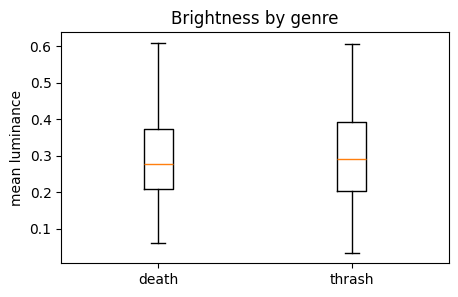

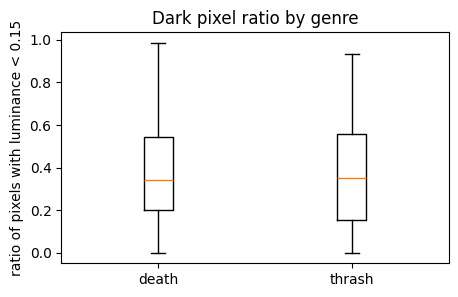

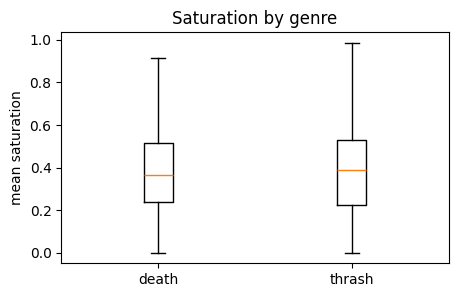

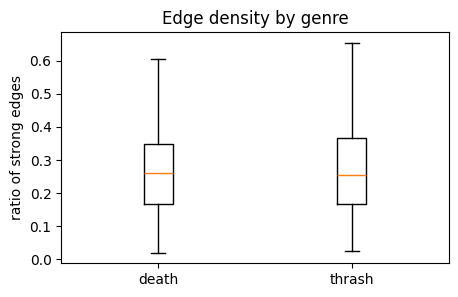

In [ ]:
def box_by_genre(col, title, ylab=None, showfliers=False):
    plt.figure(figsize=(5,3))
    data = [img_feats[img_feats.target_genre=="death"][col],
            img_feats[img_feats.target_genre=="thrash"][col]]
    plt.boxplot(data, tick_labels=["death","thrash"], showfliers=showfliers)
    plt.title(title)
    plt.ylabel(ylab or col)
    plt.show()

box_by_genre("brightness_mean", "Brightness by genre", "mean luminance", showfliers=False)
box_by_genre("dark_ratio", "Dark pixel ratio by genre", "ratio of pixels with luminance < 0.15", showfliers=False)
box_by_genre("saturation_mean", "Saturation by genre", "mean saturation", showfliers=False)
box_by_genre("edge_density", "Edge density by genre", "ratio of strong edges", showfliers=False)

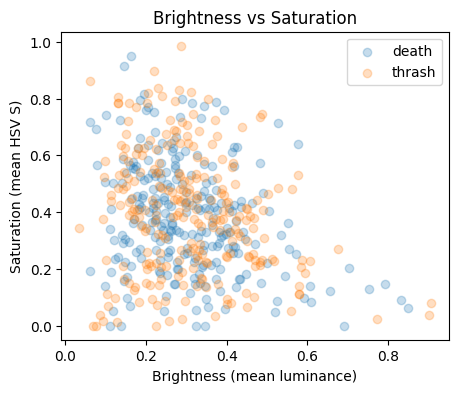

In [ ]:
plt.figure(figsize=(5,4))
for g in ["death","thrash"]:
    sub = img_feats[img_feats["target_genre"]==g]
    plt.scatter(sub["brightness_mean"], sub["saturation_mean"], alpha=0.25, label=g)

plt.xlabel("Brightness (mean luminance)")
plt.ylabel("Saturation (mean HSV S)")
plt.title("Brightness vs Saturation")
plt.legend()
plt.show()

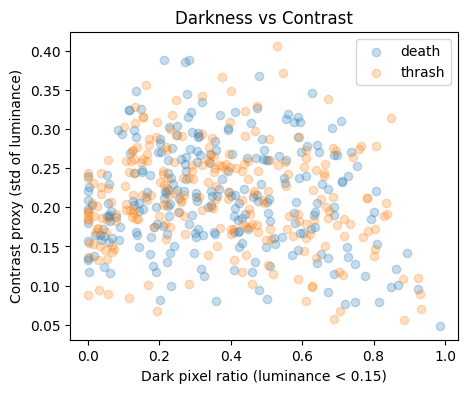

In [ ]:
plt.figure(figsize=(5,4))
for g in ["death","thrash"]:
    sub = img_feats[img_feats["target_genre"]==g]
    plt.scatter(sub["dark_ratio"], sub["brightness_std"], alpha=0.25, label=g)

plt.xlabel("Dark pixel ratio (luminance < 0.15)")
plt.ylabel("Contrast proxy (std of luminance)")
plt.title("Darkness vs Contrast")
plt.legend()
plt.show()

### Visual Feature Analysis of Album Covers

The distributions of low-level visual features are similar for death and thrash metal album covers.

**Brightness and contrast.**  
Both genres exhibit nearly identical brightness distributions and similar contrast proxies (luminance standard deviation). No clear separation is visible.

**Saturation and color tone.**  
Thrash covers are, on average, slightly more saturated than death covers, but the variance is large and the distributions overlap strongly. Mean RGB values are very similar across genres.

**Darkness.**  
The most noticeable difference appears in the *dark pixel ratio*. Death metal covers tend to contain a higher proportion of very dark pixels. However, the effect size is small and insufficient on its own.

**Texture and complexity.**  
Edge density and entropy show highly overlapping distributions - visual complexity and detail are similar for death and thrash metal.

Overall, low-level visual features capture only **weak genre-specific signals**, with darkness providing a minor cue. In conclusion - color and texture statistics alone are not sufficient for robust genre separation.

### Handcrafted feature baselines (using simple scikitlearn models)

To test whether low-level visual statistics can separate *death* vs *thrash* album covers, I trained a few standard classifiers on image features. I used:
- **Logistic Regression**
- **Random Forest**
- **HistGradientBoosting**

As assitional features, I added **colorfulness** (overall color intensity/diversity) and **sharpness** (detail/edge clarity).

In [ ]:
img_feats.columns

Index(['brightness_mean', 'brightness_std', 'saturation_mean', 'dark_ratio',
       'edge_density', 'entropy', 'mean_r', 'mean_g', 'mean_b',
       'target_genre'],
      dtype='object')

In [ ]:
# thrash metal album covers are, on average, more colorful than death metal covers
# Perhaps we could use this to our advantage and get better results
def compute_colorfulness(path):
    img = Image.open(path).convert("RGB").resize((256,256))
    arr = np.asarray(img).astype(np.float32)

    R, G, B = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    rg = np.abs(R - G)
    yb = np.abs(0.5*(R + G) - B)

    return float(np.sqrt(rg.var() + yb.var()) + 0.3*np.sqrt(rg.mean()**2 + yb.mean()**2))

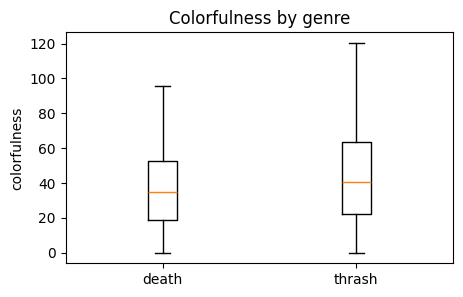

In [ ]:
tmp = sample.copy()
tmp["colorfulness"] = tmp["cover_path"].apply(compute_colorfulness)

# The plot shows the expected difference between death and thrash metal when it comes to album cover colorfulness
plt.figure(figsize=(5,3))
plt.boxplot(
    [tmp[tmp.target_genre=="death"]["colorfulness"],
     tmp[tmp.target_genre=="thrash"]["colorfulness"]],
    tick_labels=["death","thrash"],
    showfliers=False
)
plt.title("Colorfulness by genre")
plt.ylabel("colorfulness")
plt.show()

In [ ]:
def compute_sharpness(path):
    img = Image.open(path).convert("L").resize((256,256))
    arr = np.asarray(img).astype(np.float32)

    # Laplacian via finite differences
    lap = (
        -4*arr
        + np.roll(arr, 1, axis=0) + np.roll(arr, -1, axis=0)
        + np.roll(arr, 1, axis=1) + np.roll(arr, -1, axis=1)
    )
    return float(lap.var())

In [ ]:
rows = []
for _, row in sample.iterrows():
    feats = extract_image_features(row["cover_path"])
    feats["colorfulness"] = compute_colorfulness(row["cover_path"])
    feats["sharpness"] = compute_sharpness(row["cover_path"])
    feats["cover_path"] = row["cover_path"]
    feats["target_genre"] = row["target_genre"]
    rows.append(feats)

img_feats = pd.DataFrame(rows)
img_feats.head()

,brightness_mean,brightness_std,saturation_mean,dark_ratio,edge_density,entropy,mean_r,mean_g,mean_b,colorfulness,sharpness,cover_path,target_genre
0,0.383501,0.296257,0.200086,0.293152,0.372009,7.346904,0.407173,0.375104,0.396985,19.713179,3385.377197,/kaggle/working/covers/7f912ec8be9742bd616981a6a7b96a38.jpg,death
1,0.135599,0.091913,0.725076,0.671951,0.085770,5.898562,0.145094,0.127060,0.192229,72.267570,666.351440,/kaggle/working/covers/aa6253fce80081ac76b9a373813d56ad.jpg,death
2,0.203552,0.139129,0.199522,0.442841,0.236252,6.703357,0.221963,0.200115,0.183380,29.360931,1800.040771,/kaggle/working/covers/43ebf5d903d51caeec5068d8f14c9149.jpg,thrash
3,0.482261,0.273336,0.212143,0.128189,0.523361,7.920692,0.516122,0.476970,0.434961,16.545641,5376.551270,/kaggle/working/covers/dd9c11c043666cf46383f18058bcde1f.jpg,thrash
4,0.154890,0.278903,0.721453,0.808029,0.237793,3.243758,0.139430,0.157390,0.175654,16.959740,5860.751953,/kaggle/working/covers/96681db195767aeb32c1cb1784aac2b6.jpg,thrash


In [ ]:
FEATURES = [
    "brightness_mean",
    "brightness_std",
    "saturation_mean",
    "dark_ratio",
    "edge_density",
    "entropy",
    "mean_r",
    "mean_g",
    "mean_b",
    "colorfulness",
    "sharpness"
]

X = img_feats[FEATURES].copy()
y = img_feats["target_genre"].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(400, 11) (100, 11)


In [ ]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)

print("LogReg accuracy:", accuracy_score(y_test, pred))
print("LogReg F1:", f1_score(y_test, pred, average="macro"))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

LogReg accuracy: 0.44
LogReg F1: 0.4391025641025641
              precision    recall  f1-score   support

       death       0.44      0.48      0.46        50
      thrash       0.43      0.40      0.42        50

    accuracy                           0.44       100
   macro avg       0.44      0.44      0.44       100
weighted avg       0.44      0.44      0.44       100

[[24 26]
 [30 20]]


In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    max_depth=None
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("RF accuracy:", accuracy_score(y_test, pred))
print("RF F1:", f1_score(y_test, pred, average="macro"))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

RF accuracy: 0.45
RF F1: 0.44862155388471175
              precision    recall  f1-score   support

       death       0.44      0.40      0.42        50
      thrash       0.45      0.50      0.48        50

    accuracy                           0.45       100
   macro avg       0.45      0.45      0.45       100
weighted avg       0.45      0.45      0.45       100

[[20 30]
 [25 25]]


In [ ]:
imp = pd.DataFrame({"feature": FEATURES, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
imp

,feature,importance
6,mean_r,0.108630
5,entropy,0.107259
9,colorfulness,0.097243
4,edge_density,0.096040
2,saturation_mean,0.088149
3,dark_ratio,0.086200
10,sharpness,0.085632
1,brightness_std,0.084306
7,mean_g,0.083174
8,mean_b,0.083165


In [ ]:
hgb = HistGradientBoostingClassifier(
    random_state=42,
    max_depth=6,
    learning_rate=0.08
)

hgb.fit(X_train, y_train)
pred = hgb.predict(X_test)

print("HGB accuracy:", accuracy_score(y_test, pred))
print("HGB F1:", f1_score(y_test, pred, average="macro"))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

HGB accuracy: 0.45
HGB F1: 0.44862155388471175
              precision    recall  f1-score   support

       death       0.44      0.40      0.42        50
      thrash       0.45      0.50      0.48        50

    accuracy                           0.45       100
   macro avg       0.45      0.45      0.45       100
weighted avg       0.45      0.45      0.45       100

[[20 30]
 [25 25]]


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in [("LogReg", logreg), ("RandomForest", rf), ("HGB", hgb)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print(name, "CV accuracy:", scores.mean().round(3), "+/-", scores.std().round(3))

LogReg CV accuracy: 0.54 +/- 0.068
RandomForest CV accuracy: 0.568 +/- 0.069
HGB CV accuracy: 0.562 +/- 0.048


## CLIP: visual embeddings + exploratory style analysis

In this section we use **CLIP** to turn each album cover into an **embedding vector** (a representation of visual meaning).

**What is done below:**

* **Encode covers to CLIP embeddings** (image to vector)
* **Quick sanity check:** nearest-neighbor retrieval (do similar covers end up close?)
* **Exploratory clustering (KMeans):** test a few `k` values to see whether the data forms clusters
* **Interpret clusters with text concepts:** compare clusters against a small set of **hand-written concept prompts** (motifs, palette, themes) and visualize results with **heatmaps**.

**Key points**

* Metal subgenres often **overlap visually**, so perfect separation can't be expected
* The goal is to identify recurring styles and motifs that can later be useful for **prompt design** and **evaluation** for generated covers

### Results interpretation (genre separability)

Across 5-fold cross-validation, all models achieve only **moderate performance** (≈0.57–0.59 accuracy), indicating that low-level features contain **some signal** but are **not sufficient for robust classification**.

Feature importance suggests that **colorfulness** and **sharpness** are among the most informative cues, alongside entropy, saturation, and darkness.

The substantial overlap between genres implies that differences between death and thrash  are likely driven by higher level features like motifs, typography, scene content. So richer representation such as CLIP embeddings is needed.

In [ ]:
# Keep only valid images
df = df[df["cover_path"].notna()].copy()
df["cover_exists"] = df["cover_path"].map(lambda p: Path(p).exists())
df = df[df["cover_exists"]].copy()

print(df.shape)
df[["band","album","target_genre","cover_path"]].head(3)

(1665, 11)


,band,album,target_genre,cover_path
0,Bulldozer,The Day of Wrath,thrash,/kaggle/working/covers/390366afb6080f0aeaab02d58a1edb25.jpg
1,Before The Dawn,Soundscape of Silence,death,/kaggle/working/covers/d3d3bfb8ab6369c7c9136fc3a0dee2bb.jpg
2,Diabolic,Infinity Through Purification,death,/kaggle/working/covers/4a39a5877b74061d6c616bba11980905.jpg


In [ ]:
# Using a subset of all covers for this experiment
N = 800
sample = (
    df.sample(N, random_state=42)[["cover_path","target_genre","band","album"]]
    .reset_index(drop=True)
)

sample["target_genre"].value_counts()

,count
target_genre,
thrash,404
death,396


### CLIP image embedding extraction

I encode each album cover image using a pretrained CLIP image encoder
(ViT-B/32, trained on LAION). The result is a normalized embedding vector
that represents the cover in a joint image–text semantic space.

**Design choices**
- GPU is used when available to speed up batch encoding
- Embeddings are L2-normalized to enable cosine similarity comparisons
- Images are processed in batches to fit memory constraints

The resulting embedding matrix is later used for:
- nearest-neighbor retrieval
- exploratory clustering
- comparison with text-based concept prompts


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# CLIP model
model_name = "ViT-B-32"
pretrained = "laion2b_s34b_b79k"

model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
model = model.to(device).eval()

class CoverDataset(Dataset):
    def __init__(self, paths, preprocess):
        self.paths = paths
        self.preprocess = preprocess

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        return self.preprocess(img), p

paths = sample["cover_path"].tolist()
ds = CoverDataset(paths, preprocess)

batch_size = 64 if device == "cuda" else 16
dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device=="cuda"))

embs = []

with torch.no_grad():
    for batch_imgs, batch_paths in tqdm(dl, desc="Encoding covers"):
        batch_imgs = batch_imgs.to(device)
        feats = model.encode_image(batch_imgs)
        feats = feats / feats.norm(dim=-1, keepdim=True)  # normalize
        embs.append(feats.cpu().numpy().astype(np.float32))

embs = np.vstack(embs)
print("Embeddings shape:", embs.shape)

device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Encoding covers:   0%|          | 0/13 [00:00<?, ?it/s]

Embeddings shape: (800, 512)


In [ ]:
# A function used to display album covers (disabled by default for platform-safety)
def show_grid(paths, n=12, cols=6, title=""):
    if not globals().get("SHOW_IMAGES", False):
        paths = list(paths)[:n]
        print(f"SHOW_IMAGES=False; grid suppressed ({len(paths)} images prepared). Title: {title}")
        return

    paths = list(paths)[:n]
    rows = math.ceil(len(paths) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, p in enumerate(paths):
        if i >= len(axes):
            break
        img = Image.open(p).convert("RGB")
        axes[i].imshow(img)

    plt.suptitle(title)
    plt.show()


### Nearest-neighbor inspection in CLIP space

As a sanity check, I retrieve **nearest neighbors in the CLIP embedding space** using cosine similarity. For a randomly selected album cover, we display the most similar covers according to CLIP.

This helps verify that the learned embeddings capture **meaningful visual similarity** (shared color palettes, motifs, illustration styles etc.).

In [ ]:
nn = NearestNeighbors(n_neighbors=9, metric="cosine").fit(embs)

def show_neighbors(i, topk=9):
    _, idx = nn.kneighbors(embs[i:i+1], n_neighbors=topk)
    idx = idx[0]

    sub = sample.iloc[idx]
    print("Query:", sub.iloc[0][["band","album","target_genre"]].to_dict())
    show_grid(sub["cover_path"], n=topk, cols=3, title="Nearest neighbors (CLIP)")

for i in np.random.RandomState(SEED).choice(len(sample), size=2, replace=False):
    show_neighbors(i, topk=9)

Query: {'band': 'Vengeance Rising', 'album': 'Released Upon The Earth', 'target_genre': 'thrash'}
SHOW_IMAGES=False; grid suppressed (9 images prepared). Title: Nearest neighbors (CLIP)
Query: {'band': 'Vader', 'album': 'Revelations', 'target_genre': 'death'}
SHOW_IMAGES=False; grid suppressed (9 images prepared). Title: Nearest neighbors (CLIP)


### 2D projection of CLIP embeddings (genre coloring)

Since the CLIP embedding space is 512-dimensional, I do **dimensionality reduction** in order to plot the image embeddings in 2D. I am using **PCA**. The points represent album covers and are colored by the genre label - death or thrash metal.

The purpose of this is to check whether any genre-related structure is visible and to show the degree of visual overlap between thrash and death metal.

In [ ]:
def plot_2d(Z, labels, title="", alpha=0.55, s=12, legend=True):
    plt.figure(figsize=(6,5))
    labels = np.asarray(labels)
    for v in sorted(pd.unique(labels)):
        m = (labels == v)
        plt.scatter(Z[m,0], Z[m,1], alpha=alpha, s=s, label=str(v))
    plt.title(title)
    plt.xlabel("dim1")
    plt.ylabel("dim2")
    if legend:
        plt.legend()
    plt.show()

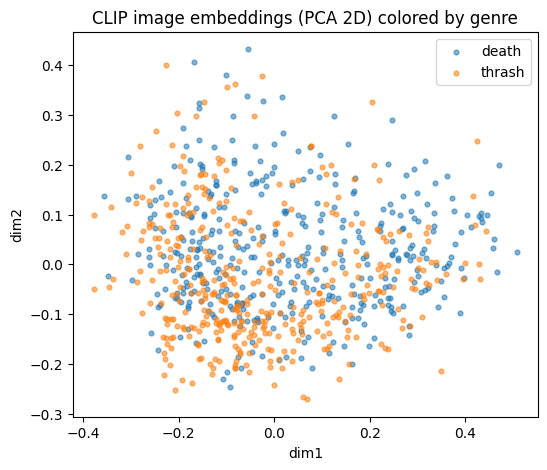

In [ ]:
y = sample["target_genre"].values
Z_pca = PCA(n_components=2, random_state=SEED).fit_transform(embs)

plot_2d(Z_pca, y, title="CLIP image embeddings (PCA 2D) colored by genre")

### Choosing *k*: clustering quality and stability (KMeans on CLIP embeddings)

I apply **KMeans** to the CLIP image embeddings and evaluate several values of *k* (number of clusters). Since KMeans can produce different results depending on initialization, I run it across multiple random seeds.

**Metrics**

* **Silhouette score (mean ± std):** indicates how well-separated the clusters are in embedding space *(higher is better)*.
* **ARI stability vs. a reference run:** compares cluster assignments across seeds using **Adjusted Rand Index** *(1.0 = identical clustering; ~0 = inconsistent)*.
  * **ARI mean:** typical stability
  * **ARI min:** worst-case stability

In [ ]:
def eval_kmeans_multiseed(X, k, seeds, n_init=10):
    labels_by_seed = []
    sils = []

    for s in seeds:
        km = KMeans(n_clusters=k, random_state=s, n_init=n_init)
        labels = km.fit_predict(X)
        labels_by_seed.append(labels)
        sils.append(silhouette_score(X, labels))

    ref = labels_by_seed[0]
    ari_vs_ref = [adjusted_rand_score(ref, lab) for lab in labels_by_seed[1:]]
    return (
        np.array(sils, dtype=np.float32),
        float(np.mean(ari_vs_ref)),
        float(np.min(ari_vs_ref)),
    )

seeds = list(range(10))
rows = []

for k in range(2, 13):
    sils, ari_mean, ari_min = eval_kmeans_multiseed(embs, k=k, seeds=seeds, n_init=10)
    rows.append({
        "k": k,
        "sil_mean": float(sils.mean()),
        "sil_std": float(sils.std()),
        "ARI_mean_vs_ref": ari_mean,
        "ARI_min_vs_ref": ari_min,
    })

summary_df = pd.DataFrame(rows)
display(summary_df.round(4))

,k,sil_mean,sil_std,ARI_mean_vs_ref,ARI_min_vs_ref
0,2,0.0316,0.0003,0.9723,0.9651
1,3,0.0289,0.0013,0.8530,0.7676
2,4,0.0282,0.0027,0.7324,0.5134
3,5,0.0200,0.0036,0.5738,0.4292
4,6,0.0138,0.0047,0.4891,0.3569
5,7,0.0149,0.0038,0.4210,0.3193
6,8,0.0122,0.0061,0.3219,0.2666
7,9,0.0091,0.0036,0.3465,0.2734
8,10,0.0104,0.0057,0.3085,0.2657
9,11,0.0049,0.0034,0.2991,0.2585


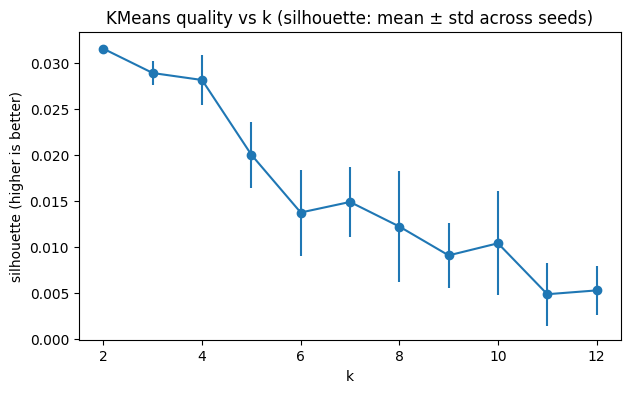

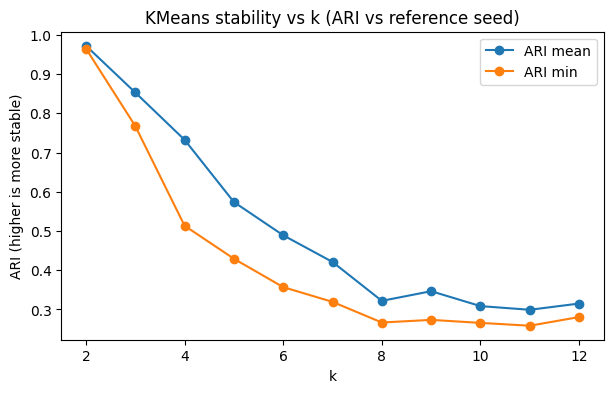

In [ ]:
kvals = summary_df["k"].values

# Silhouette (quality)
plt.figure(figsize=(7,4))
plt.errorbar(kvals, summary_df["sil_mean"], yerr=summary_df["sil_std"], marker="o")
plt.title("KMeans quality vs k (silhouette: mean ± std across seeds)")
plt.xlabel("k")
plt.ylabel("silhouette (higher is better)")
plt.show()

# ARI (stability)
plt.figure(figsize=(7,4))
plt.plot(kvals, summary_df["ARI_mean_vs_ref"], marker="o", label="ARI mean")
plt.plot(kvals, summary_df["ARI_min_vs_ref"], marker="o", label="ARI min")
plt.title("KMeans stability vs k (ARI vs reference seed)")
plt.xlabel("k")
plt.ylabel("ARI (higher is more stable)")
plt.legend()
plt.show()

### Interpretation of KMeans results

**Overall separation is weak.**  
Silhouette scores are very low for all *k* (≤ 0.03), which means the CLIP image embeddings do not form well-separated, compact clusters.

**k = 2 is the most reliable structure.**
- Highest silhouette score (≈ 0.031)
- Very high stability across random seeds (ARI mean ≈ 0.96, min ≈ 0.92)
- Since I am working with thrash and death metal, this result is expected and desired
- Hopefully after adding context the quality of the clusters will become better
  
**As k increases, structure weakens.**
- Silhouette decreases monotonically
- ARI drops quickly, meaning cluster assignments become unstable

**Bottom line**
* CLIP embeddings clearly support a **simple split (k=2)**.
* More detailed splits yield worse results

In [ ]:
tokenizer = open_clip.get_tokenizer(model_name)

### Interpreting clusters with text 'concept prompts' (CLIP image-text similarity)

I define a small set of text prompts that describe common visual concepts of metal album covers (related to color palette, motifs, themes and art style). Then, I do the following:

- Encode each concept prompt with CLIP’s **text encoder**
- Compare images to concepts using **cosine similarity**
- For each cluster, compute the **average similarity** to each concept prompt

This is done in order to interpret the content of the clusters - whether the covers that fall into them have common visual motifs and whether there are significant differences between the clusters in this regard.

**Output**
- A **heatmap** shows the concept profile of each cluster:
  - rows = clusters  
  - columns = concepts (only the most informative ones, i.e., those that vary most across clusters)
- A small grid of **example covers per cluster**

In [ ]:
concept_prompts = {
    # palette / lighting
    "very dark / low-key": "very dark album cover, low-key lighting, black background",
    "high contrast / stark": "high contrast stark album cover artwork",
    "red/black palette": "album cover with red and black color palette",
    "blue/teal palette": "album cover with blue or teal color palette",
    "warm fiery palette": "album cover with fiery warm colors, orange and red tones",
    "desaturated / muted": "desaturated muted album cover artwork",

    # death metal-ish motifs
    "gore / organs": "album cover art showing gore, organs, gruesome horror illustration",
    "corpse / decay": "album cover with corpse, decay, rot, macabre imagery",
    "necromancy / undead": "album cover with undead creatures, necromancy theme",
    "crypt / tomb": "album cover with crypt, tomb, graveyard, cemetery scene",
    "biomechanical horror": "album cover with biomechanical horror creature, alien anatomy",

    # thrash metal-ish motifs
    "apocalyptic city": "album cover with apocalyptic city, destruction, ruins, chaos",
    "war / nuclear": "album cover showing war, tanks, explosions, nuclear blast",
    "riot / aggression": "album cover depicting riot, aggression, chaotic crowd",
    "sci-fi dystopia": "album cover with sci-fi dystopia, futuristic war, cyber theme",

    # shared/common motifs
    "skulls": "album cover with skulls, skull imagery",
    "skeletons": "album cover with skeletons",
    "demon / hell": "album cover with demonic hellish imagery, devil figure",
    "occult symbols": "album cover with occult symbols, pentagram, ritual imagery",
    "monster creature": "album cover with a large monster creature illustration",
    "fire / flames": "album cover with fire and flames",

    # artwork style
    "detailed illustration": "highly detailed illustrated album cover art",
    "painted artwork": "painted album cover artwork, painterly style",
    "comic style": "album cover illustration in comic-book style",
}

concept_names = list(concept_prompts.keys())
concept_texts = list(concept_prompts.values())

with torch.no_grad():
    text_tokens = tokenizer(concept_texts).to(device)
    text_feats = model.encode_text(text_tokens)
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

concept_feats = text_feats.cpu().numpy().astype(np.float32)  # (M, D)

print("Encoded concept prompts:", len(concept_names))

Encoded concept prompts: 24


In [ ]:
np.savez(
    WORK / "clip_concept_feats.npz",
    names=np.array(concept_names),
    feats=concept_feats
)

print("Saved concept embeddings:", concept_feats.shape)
print("Path:", out_path)

Saved concept embeddings: (24, 512)
Path: /content/drive/MyDrive/metal_album_cover_project/working/master_death_thrash_with_covers.parquet


In [ ]:
def cluster_concept_means(embs, concept_feats, clusters):
    sims = embs @ concept_feats.T  # (N, M)
    K = int(np.max(clusters)) + 1
    mat = np.zeros((K, sims.shape[1]), dtype=np.float32)
    for c in range(K):
        idx = np.where(clusters == c)[0]
        mat[c] = sims[idx].mean(axis=0)
    return mat

def plot_concept_heatmap(mat, concept_names, title="", top_m=12):
    # show only concepts that vary most across clusters (most informative)
    var = mat.var(axis=0)
    keep = np.argsort(-var)[:min(top_m, len(concept_names))]

    mat2 = mat[:, keep]
    names2 = [concept_names[i] for i in keep]

    plt.figure(figsize=(min(14, 1 + 0.6*len(names2)), 1 + 0.6*mat.shape[0]))
    plt.imshow(mat2, aspect="auto")
    plt.colorbar(label="mean CLIP similarity")
    plt.yticks(range(mat.shape[0]), [f"C{i}" for i in range(mat.shape[0])])
    plt.xticks(range(len(names2)), names2, rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

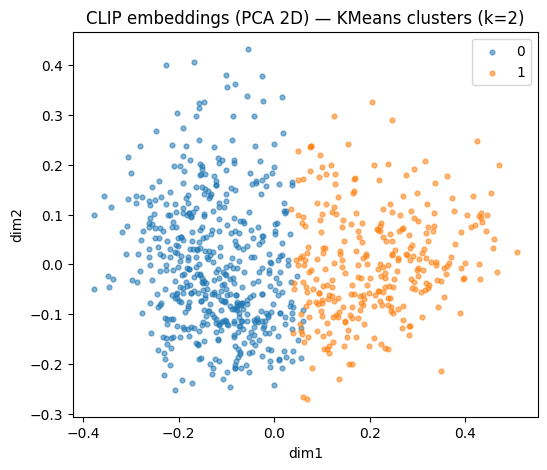

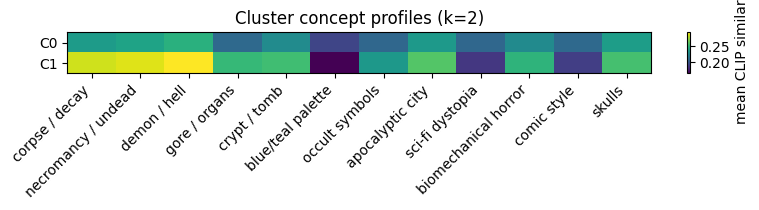

target_genre,death,thrash
Cluster 0,44.2,55.8
Cluster 1,58.6,41.4
Overall sample,49.5,50.5


SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=2 — Cluster 0 samples
SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=2 — Cluster 1 samples


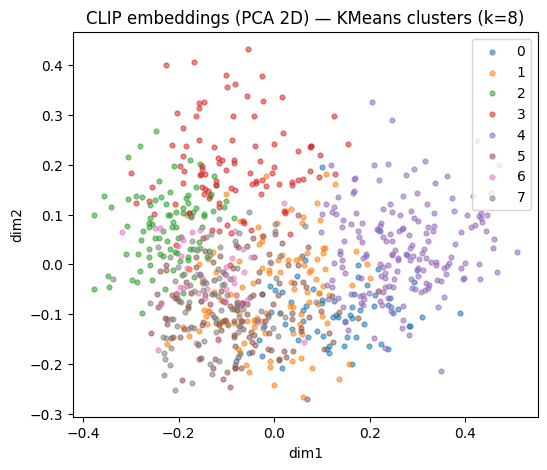

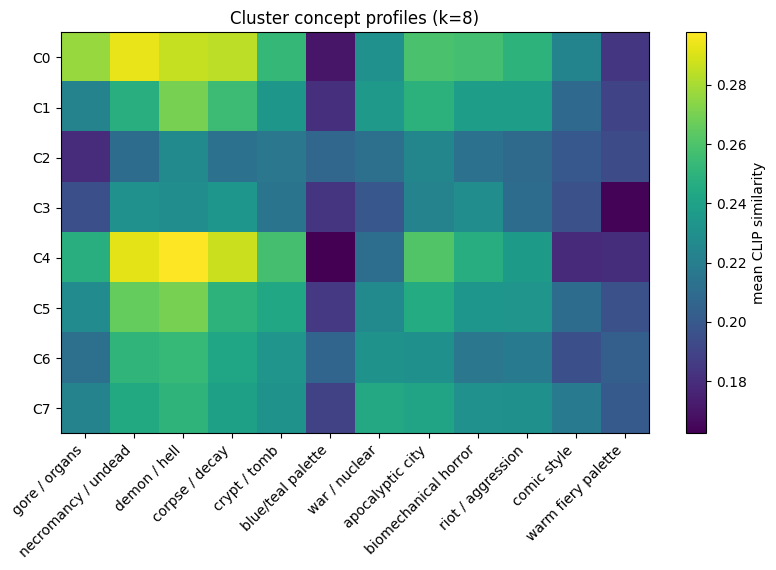

target_genre,death,thrash
Cluster 0,45.6,54.4
Cluster 1,39.1,60.9
Cluster 2,50.5,49.5
Cluster 3,57.7,42.3
Cluster 4,61.3,38.7
Cluster 5,43.5,56.5
Cluster 6,54.8,45.2
Cluster 7,38.6,61.4
Overall sample,49.5,50.5


SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=8 — Cluster 0 samples
SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=8 — Cluster 1 samples
SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=8 — Cluster 2 samples
SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=8 — Cluster 3 samples
SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=8 — Cluster 4 samples
SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=8 — Cluster 5 samples
SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=8 — Cluster 6 samples
SHOW_IMAGES=False; grid suppressed (4 images prepared). Title: k=8 — Cluster 7 samples


In [ ]:
concept_names = list(concept_prompts.keys())

for k in [2, 8]:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    clusters = km.fit_predict(embs)

    # Scatter: shows whether clusters form visible neighborhoods in 2D
    plot_2d(Z_pca, clusters, title=f"CLIP embeddings (PCA 2D) — KMeans clusters (k={k})", legend=(k <= 10))

    # Heatmap: shows which concepts separate clusters (compact + interpretable)
    mat = cluster_concept_means(embs, concept_feats, clusters)
    plot_concept_heatmap(mat, concept_names, title=f"Cluster concept profiles (k={k})", top_m=12)

    tmp = sample.copy()
    tmp["cluster"] = clusters

    cluster_genre_pct = (
    pd.crosstab(tmp["cluster"], tmp["target_genre"], normalize="index") * 100
    ).round(1)
    cluster_genre_pct.index = [f"Cluster {i}" for i in cluster_genre_pct.index]

    overall_pct = (
        tmp["target_genre"].value_counts(normalize=True).mul(100).round(1).to_frame().T
    )
    overall_pct.index = ["Overall sample"]

    display(pd.concat([cluster_genre_pct, overall_pct], axis=0))

    for c in range(k):
        sub = tmp[tmp["cluster"] == c].sample(
            min(4, (tmp["cluster"] == c).sum()),
            random_state=SEED
        )
        show_grid(sub["cover_path"], n=len(sub), cols=4, title=f"k={k} — Cluster {c} samples")

#### Interpretation of clustering and concept analysis

The results confirm that **visual styles of death and thrash metal album covers strongly overlap**.  
In the **k = 2** setting, the clusters show weak separation - the genre distributions remain close to the overall dataset balance.

For **k = 8**, the clusters break into smaller visual groups, but these groups are **not clearly separated by genre**.

Overall, the clustering does not produce clean or genre-pure clusters. This supports the conclusion that CLIP embeddings capture shared aesthetic patterns across metal subgenres rather than strict genre distinctions.

### Zero-shot genre matching with CLIP prompts

In this experiment, I test whether CLIP can distinguish **death metal** and **thrash metal** album covers using only **text prompts**, without any supervised training.  
Each cover image embedding is compared to two genre-specific text embeddings, and the genre with the higher similarity score is selected.

The goal is to assess how strongly genre information is reflected in the visual features captured by CLIP.

**Results**
- **Zero-shot accuracy:** 57.9%
- **Recall (death):** 80.2%
- **Recall (thrash):** 35.1%

The confusion matrix shows that death metal covers are identified relatively well, while many thrash metal covers are misclassified as death metal. This asymmetry suggests that **death metal imagery has stronger and more distinctive visual cues**, which CLIP matches more easily to text prompts. In contrast, thrash metal visuals overlap more with general metal aesthetics, making them harder to separate.

Overall, the results indicate that CLIP captures **some genre-related visual signals**, but these signals are weak. This aligns with earlier clustering results and supports the conclusion that **metal subgenres are not cleanly separable based on cover art alone**.

In [ ]:
prompts = {
    "death": "death metal album cover artwork, gruesome horror illustration, corpse decay, crypt, gore, dark desaturated colors",
    "thrash": "thrash metal album cover artwork, apocalyptic war scene, nuclear explosion, riot chaos, aggressive comic-style illustration, bold colors",
}

text_tokens = tokenizer(list(prompts.values())).to(device)

with torch.no_grad():
    text_feats = model.encode_text(text_tokens)
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
text_feats = text_feats.cpu().numpy().astype(np.float32)  # shape: (2, D)

# cosine similarity since vectors are normalized -> dot product
sims = embs @ text_feats.T  # shape: (N, 2)
pred_idx = sims.argmax(axis=1)
classes = list(prompts.keys())
pred = np.array([classes[i] for i in pred_idx])

acc = (pred == y).mean()
print("Zero-shot accuracy:", acc)

cm = confusion_matrix(y, pred, labels=classes)
print("Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(cm, index=[f"true_{c}" for c in classes], columns=[f"pred_{c}" for c in classes]))

recall = cm.diagonal() / cm.sum(axis=1)
print("Recall per class:", {classes[i]: round(float(recall[i]), 3) for i in range(len(classes))})

Zero-shot accuracy: 0.56625
Confusion matrix (rows=true, cols=pred):
             pred_death  pred_thrash
true_death          314           82
true_thrash         265          139
Recall per class: {'death': 0.793, 'thrash': 0.344}


In [ ]:
df.head()

,key,band,album,target_genre,album_cover_url,lyrics_full,n_songs,lyrics_len,cover_path,download_ok,cover_exists
0,bulldozer||the day of wrath,Bulldozer,The Day of Wrath,thrash,https://is3-ssl.mzstatic.com/image/thumb/Music114/v4/ed/ee/28/edee2874-0fd4-edc4-c3af-228b782ca740/source/512x512.jpg,[Instrumental]\n\n\nOne life here\nOne soul there\nI'm bored with living\nI don't even care\nSuck up their brain\nRi...,9,4744,/kaggle/working/covers/390366afb6080f0aeaab02d58a1edb25.jpg,True,True
1,before the dawn||soundscape of silence,Before The Dawn,Soundscape of Silence,death,https://is2-ssl.mzstatic.com/image/thumb/Music111/v4/de/75/7a/de757a4d-102d-6886-61c4-099ea974eb53/source/512x512.jpg,By the powers vested in me\nBy the entity of choice\nI pronounce myself dead\nAt 4:18 am\nI am gathered here\nTo rem...,10,4912,/kaggle/working/covers/d3d3bfb8ab6369c7c9136fc3a0dee2bb.jpg,True,True
2,diabolic||infinity through purification,Diabolic,Infinity Through Purification,death,https://is2-ssl.mzstatic.com/image/thumb/Music/v4/40/2f/1a/402f1aaa-f18e-1cc5-9ad0-4b7011397e1e/source/512x512.jpg,[Hersemann/Malone]\n\nAll our futures once were foretold\nFirst etched stone now carved flesh\nDespite our frail hum...,8,7943,/kaggle/working/covers/4a39a5877b74061d6c616bba11980905.jpg,True,True
3,nocturnal rites||new world messiah,Nocturnal Rites,New World Messiah,death,https://is2-ssl.mzstatic.com/image/thumb/Music6/v4/53/8e/84/538e8479-a333-ae50-86e9-76fa4cd05ce3/source/512x512.jpg,"Alone in a world of silence, I'm crawling in you\nI won't ever betray your trust, feel me - I subdue\nTrust you seek...",12,7140,/kaggle/working/covers/4b2a8414f5a951c4379838b0f9a3a9fa.jpg,True,True
4,pentagram chile||the malefice,Pentagram Chile,The Malefice,thrash,https://is1-ssl.mzstatic.com/image/thumb/Music4/v4/b4/e1/2a/b4e12aa3-b509-aca8-d2a0-0bba3ffadad9/source/512x512.jpg,"Eternal foe, antagonist\nopposite poles mutually destruct\nevil and good, heaven and hell\ncontradictory collapsing ...",17,9681,/kaggle/working/covers/939dd52eb97014245a6e30de3f70e481.jpg,True,True


In [ ]:
df.shape

(1665, 11)

### Text Cleaning and Preprocessing of Lyrics

Before constructing text prompts from song lyrics, the raw lyrical data is cleaned and normalized to reduce noise and ensure that the information reflects meaningful content.

The preprocessing pipeline includes the following steps:

- **Lowercasing** all text to ensure consistency.
- **Removal of bracketed annotations** such as `[chorus]`, `[verse]`, or `[instrumental]`, which are common in lyrics datasets but do not carry meaning.
- **Removal of URLs** and other non-lyrical artifacts.
- **Normalization of apostrophes**
- **Filtering of non-alphabetic characters** - keep only lowercase letters and whitespace.
- **Whitespace normalization** - collapse multiple spaces into a single space.

In addition to general English stopwords, an extended set of **domain-specific stopwords** is used. These include:
- Common vocal fillers (e.g., *yeah*, *oh*, *ah*)
- Structural music terms (e.g., *chorus*, *solo*)
- Weak or generic verbs frequently used in lyrics
- Band-related metadata words
- Conversational fillers and profanities
- Foreign function words (German, French, Italian, Spanish), which sometimes appear in metal lyrics

Finally, consecutive duplicate words are removed (e.g., *"die die die"* is transformed to *"die"*) to reduce repetition bias

Only lyrics detected as English are used.  
The result is a cleaned lyrics corpus suitable for TF–IDF analysis and prompt construction.

In [ ]:
BRACKET_RE = re.compile(r"\[[^\]]*\]")  # remove anything inside []

def clean_lyrics(text: str) -> str:
    if not isinstance(text, str):
        return ""

    t = text.lower()

    # remove [] tags like [chorus] and [instrumental]
    t = BRACKET_RE.sub(" ", t)

    # remove urls if any
    t = re.sub(r"http\S+|www\.\S+", " ", t)

    # normalize apostrophes
    t = t.replace("’", "'")
    # remove apostrophes
    t = t.replace("'", "")

    # keep letters, spaces and apostrophes
    t = re.sub(r"[^a-z\s']", " ", t)

    # collapse whitespace
    t = re.sub(r"\s+", " ", t).strip()

    return t

In [ ]:
METAL_STOP_WORDS = {
    # common when singing in general
    "yeah", "yea", "yo", "oh", "ooh", "woah", "woahh", "woooo",
    "ah", "aah", "na", "la", "hey", "ha", "haa", "haaa",
    "ya", "yah", "nah", "yep", "nope",
    "whoa", "whoah",
    "cmon", "comeon",
    "uh", "uhh", "uhhh",

    # structural and lyrics
    "chorus", "verse", "solo", "interlude", "repeat", "instrumental",

    # very weak verbs often found in lyrics
    "let", "gonna", "gotta", "got", "wanna", "like",

    # Band-related and attributions
    "thanks", "thank", "thx",
    "lyrics", "lyric",
    "track", "tracks",
    "correcting", "corrected",
    "additional", "backing",
    "vocals", "vocal", "voice",
    "guitar", "guitars", "acoustic", "instruments", "instrument",
    "bass", "drums", "drum",
    "mixing", "mastering", "engineer", "produced", "recorded", "music",
    "album","band","song","songs",
    "written","performed","composed",
    "feat","ft",

    # Archaic pronouns
    "thou","thee","thy","thine","ye",
    "tis","hath","hast","doth",
    "shalt","shall",
    "unto","afar","whilst"
}

CONTRACTION_FRAGMENTS = {
    "im","ive","id","ill","youre","youve","youd","youll",
    "were","weve","wed",
    "theyre","theyve","theyd","theyll",
    "isnt","arent","wasnt","werent","dont","doesnt","didnt",
    "cant","couldnt","wont","wouldnt","shouldnt",
    "ain","aint",
    "ve","ll","re","d","m","s","t",
    "hes","shes","thats","theres","heres","whats","wheres",
    "wholl","therell","thatll","thisll"
}

GLUE_PHRASES = {
    # cognitive and speech verbs
    "know","knows","knew",
    "say","says","said",
    "tell","tells","told",
    "feel","feels","felt",

    # motion and action
    "come","comes","coming",
    "go","goes","going","gone",
    "make","makes","made",
    "get","gets","gotten",
    "try","tries","tried",
    "want","wants","wanted",
    "need","needs","needed",

    "just","really","still",
    "away","lot","way",
    "moment","times",

    # weak evaluation
    "good","bad","better",
    "thing","things",

    # Time-related
    "today", "tonight", "yesterday",
    "tomorrow", "forever", "never",
    "always", "sometimes",
    "again", "already",
    "soon", "late",
    "once", "twice",
    "years", "days", "hours",
}

FOREIGN_FUNCTION_WORDS = {
  # German
  "und","der","die","das","den","dem","zu","ein","eine","einer","euch","ihr","wir","ich","du","er","es","nicht","mein","meine","auf",

  # French
  "je","tu","il","elle","le","la","les","des","du","de","dans","que","qui","sur","pas",

  # Italian
  "io","tu","il","lo","la","gli","le","che","del","dei","sono","ti","mi",

  # Spanish and Portuguese
  "el","la","los","las","una","uno","que","por","para","mas","vez","nos","se","te","mi","yo"
}

BAD_TOKEN_ARTIFACTS = {
  "amp","ov",
  "til","'til","till",
  "cuz","coz","cos",
  "ii","iii","iv","vi","vii","viii","ix","x"
}

PROFANITY = set()  # removed explicit terms for platform-safety

CONVERSATIONAL_FILLER = {
    "okay", "ok", "alright", "right",
    "huh","hmm", "hmmm",
    "yeahyeah", "nahnah",
    "who", "what", "why", "when", "where"
}

ADDRESS_WORDS = {
    "somebody", "anybody", "everybody", "nobody",
    "someone", "anyone", "everyone", "noone",
    "baby", "babies",
    "man", "men", "woman", "women",
    "child", "children",
}

print("Initial stopwords", len(ENGLISH_STOP_WORDS))

STOPWORDS = {
    *ENGLISH_STOP_WORDS,
    *METAL_STOP_WORDS,
    *CONTRACTION_FRAGMENTS,
    *GLUE_PHRASES,
    *FOREIGN_FUNCTION_WORDS,
    *BAD_TOKEN_ARTIFACTS,
    *PROFANITY,
    *CONVERSATIONAL_FILLER,
    *ADDRESS_WORDS,
}

print("Stopwords after adding metal stopwords:", len(STOPWORDS))

Initial stopwords 318
Stopwords after adding metal stopwords: 596


In [ ]:
def dedupe_consecutive_words(text: str) -> str:
    words = text.split()
    if not words:
        return text

    deduped = [words[0]]
    for w in words[1:]:
        if w != deduped[-1]:
            deduped.append(w)

    return " ".join(deduped)

In [ ]:
def detect_lang_safe(text):
    try:
        return detect(text)
    except:
        return "unknown"

df["lyrics_lang"] = df["lyrics_full"].apply(detect_lang_safe)

In [ ]:
df["lyrics_lang"].value_counts().head(10)

,count
lyrics_lang,
en,1619
es,19
de,8
fi,5
da,3
pt,3
sv,2
id,2
fr,2


In [ ]:
df_en = df[df["lyrics_lang"] == "en"].copy()
df_en.head()

,key,band,album,target_genre,album_cover_url,lyrics_full,n_songs,lyrics_len,lyrics_lang
0,bulldozer||the day of wrath,Bulldozer,The Day of Wrath,thrash,https://is3-ssl.mzstatic.com/image/thumb/Music...,[Instrumental]\n\n\nOne life here\nOne soul th...,9,4744,en
1,before the dawn||soundscape of silence,Before The Dawn,Soundscape of Silence,death,https://is2-ssl.mzstatic.com/image/thumb/Music...,By the powers vested in me\nBy the entity of c...,10,4912,en
2,diabolic||infinity through purification,Diabolic,Infinity Through Purification,death,https://is2-ssl.mzstatic.com/image/thumb/Music...,[Hersemann/Malone]\n\nAll our futures once wer...,8,7943,en
3,nocturnal rites||new world messiah,Nocturnal Rites,New World Messiah,death,https://is2-ssl.mzstatic.com/image/thumb/Music...,"Alone in a world of silence, I'm crawling in y...",12,7140,en
4,pentagram chile||the malefice,Pentagram Chile,The Malefice,thrash,https://is1-ssl.mzstatic.com/image/thumb/Music...,"Eternal foe, antagonist\nopposite poles mutual...",17,9681,en


In [ ]:
df_en["lyrics_lang"].value_counts().head(10)

,count
lyrics_lang,
en,1619


In [ ]:
df_en["lyrics_clean"] = (
    df_en["lyrics_full"]
      .map(clean_lyrics)
      .map(dedupe_consecutive_words)
)

# quick checks
print("Empty cleaned lyrics:", (df_en["lyrics_clean"].str.len() == 0).mean().round(3))

# show a couple examples
df_en[["band", "album", "target_genre", "lyrics_len", "lyrics_clean"]].sample(3, random_state=SEED)

Empty cleaned lyrics: 0.0


,band,album,target_genre,lyrics_len,lyrics_clean
1172,Cauldron,In Ruin,thrash,6844,take no prisoners feel no pain overseeing endless reign unknown body staking claim changing seasons all the same sta...
356,Grave Digger,Clash of the Gods,thrash,9042,weiche wellen wiegen sich mein ruder bricht den fluss tote seelen nehme ich mit einem letzten kuss ich bin charon fa...
528,Death Threat,Last Dayz,thrash,3930,waiting for the end as your life wastes away no regrets too late to repent were living in the last dayz i see death ...


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.5,
    max_features=20000
)

X = vectorizer.fit_transform(df_en["lyrics_clean"])
feat_names = vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (1619, 20000)


In [ ]:
def get_top_terms(row_idx, top_n=15):
    row = X[row_idx].toarray().ravel()
    top_idx = row.argsort()[-top_n:][::-1]
    return feat_names[top_idx].tolist()

In [ ]:
df_en["tfidf_terms"] = [get_top_terms(i, top_n=15) for i in range(len(df_en))]

In [ ]:
for i in df_en.sample(5, random_state=SEED).index:
    r = df_en.loc[i]
    print(f"\n=== {r['band']} — {r['album']} ({r['target_genre']}) ===")
    print(", ".join(r["tfidf_terms"]))


=== Cauldron — In Ruin (thrash) ===
corridors, gather round, dust, compel, empire fall, santa, proclaiming, confine, withdrawn, sink, deprive, numbing, wrath, survives, long

=== Grave Digger — Clash of the Gods (thrash) ===
broken souls, saints, home, souls, medusa, broken, end day, gods, regrets, digger, changing, souls collide, charon, spell hell, faith

=== Death Threat — Last Dayz (thrash) ===
old new, stay true, handed, true, stay, chose path, burnin, pain caused, talkin, friends, nothin, love, trend, time open, eyes time

=== Barren Earth — A Complex of Cages (death) ===
ruby, harbour, codes, sides, enclosure, opening, lashing, fortress, colour, sightless, ghostly, waves, shard, skywards, roared

=== Opeth — Sorceress (death) ===
funeral pyre, light flames, grow higher, flames grow, pyre, tired waiting, blinding light, waiting, searing, funeral, time waits, blinding, mikael, sigh, waiting waiting


### Prompt Construction for Image Generation

To support different levels of conditioning for album cover generation, three types of text prompts are constructed automatically for each album:

#### G — Metadata-Based Prompt
The **G prompt** encodes only high-level metadata:
- musical subgenre
- band name
- album title

This prompt represents a minimal conditioning scenario and serves as a baseline:
> *"Album cover for a thrash metal album by Kreator, titled 'Coma of Souls'."*

#### L — Lyrics-Based Prompt
The **L prompt** is derived exclusively from song lyrics.  
After preprocessing, TF–IDF is applied at the album level to extract the most distinctive unigrams and bigrams.

Note: A 1-gram (unigram) is a single word sequence of words like “desperation” or “napalm”. A 2-gram (bigram) is a two-word sequence of words like “enslave world”, “voices calling” etc.

The top-ranked terms are interpreted as **dominant lyrical themes** and inserted into a structured natural-language description:
> *"Album cover inspired by these lyrical themes: death ritual, burning cross, decay, torment... Dark, atmospheric, detailed illustration."*

This approach avoids passing raw lyrics directly to the model and instead summarizes important lyrical content.

#### GL — Combined Prompt
The **GL prompt** concatenates the metadata-based (G) and lyrics-based (L) descriptions into a single prompt:
> *"Album cover for a thrash metal album by Kreator, titled 'Coma of Souls'. Album cover inspired by these lyrical themes: ..."*


The three prompt types enable controlled experiments on how different sources of textual information influence the generated album covers.

In [ ]:
def make_prompt_G(row):
    genre = row["target_genre"]
    band = row["band"]
    album = row["album"]
    return f"Album cover for a {genre} metal album by {band}, titled '{album}'."

In [ ]:
def make_prompt_L_from_terms(terms):
    # terms is a list like, for example [burn cross, vanquish, shun, illumination]
    terms = [t.replace("_", " ") for t in terms]
    core = ", ".join(terms[:10])
    extra = ", ".join(terms[10:15])
    return (
        f"Album cover inspired by these lyrical themes: {core}. "
        f"Additional motifs: {extra}. Dark, atmospheric, detailed illustration."
    )

In [ ]:
def make_prompt_GL(row, terms):
    return make_prompt_G(row) + " " + make_prompt_L_from_terms(terms)

In [ ]:
df_en = df_en.reset_index(drop=True)

X = vectorizer.fit_transform(df_en["lyrics_clean"])
feat_names = vectorizer.get_feature_names_out()

def get_top_terms(row_idx, top_n=15):
    row = X[row_idx].toarray().ravel()
    top_idx = row.argsort()[-top_n:][::-1]
    return feat_names[top_idx].tolist()

df_en["top_terms"] = [get_top_terms(i, top_n=15) for i in range(len(df_en))]

df_en["prompt_G"]  = df_en.apply(make_prompt_G, axis=1)
df_en["prompt_L"]  = df_en["top_terms"].apply(make_prompt_L_from_terms)
df_en["prompt_GL"] = df_en.apply(lambda r: make_prompt_GL(r, r["top_terms"]), axis=1)

In [ ]:
df_en[["band","album","target_genre","prompt_G","prompt_L","prompt_GL"]].sample(3, random_state=SEED)

,band,album,target_genre,prompt_G,prompt_L,prompt_GL
1143,Cauldron,In Ruin,thrash,"Album cover for a thrash metal album by Cauldron, titled 'In Ruin'.","Album cover inspired by these lyrical themes: corridors, gather round, dust, compel, empire fall, santa, proclaiming...","Album cover for a thrash metal album by Cauldron, titled 'In Ruin'. Album cover inspired by these lyrical themes: co..."
344,Grave Digger,Clash of the Gods,thrash,"Album cover for a thrash metal album by Grave Digger, titled 'Clash of the Gods'.","Album cover inspired by these lyrical themes: broken souls, saints, home, souls, medusa, broken, end day, gods, regr...","Album cover for a thrash metal album by Grave Digger, titled 'Clash of the Gods'. Album cover inspired by these lyri..."
513,Death Threat,Last Dayz,thrash,"Album cover for a thrash metal album by Death Threat, titled 'Last Dayz'.","Album cover inspired by these lyrical themes: old new, stay true, handed, true, stay, chose path, burnin, pain cause...","Album cover for a thrash metal album by Death Threat, titled 'Last Dayz'. Album cover inspired by these lyrical them..."


### Sanity Check: CLIP-Based Prompt Similarity

Before image generation, a sanity check is performed to validate the semantic relationships between the three prompt types (G, L, GL).

All prompts are encoded using the CLIP text encoder and compared using cosine similarity:

- **sim(G, GL)** evaluates whether the combined prompt preserves album metadata
- **sim(G, L)** measures semantic overlap between metadata and lyrics-based content
- **sim(L, GL)** checks whether lyrical themes are reflected in the combined prompt

Expected behavior is **high sim(G, GL), lower sim(G, L), and moderate sim(L, GL)**.

Observed similarities follow this pattern: sim(G, GL) is consistently high (≈ 0.8–0.9), sim(G, L) is low (≈ 0.15–0.30), and sim(L, GL) is moderate (≈ 0.35–0.45). This indicates that lyrics-based prompts encode complementary information and that GL successfully integrates both sources.

Simple heuristics are used to flag edge cases where lyrical information is either redundant or insufficient.

Overall, the results confirm that the prompt construction is coherent and suitable for diffusion-based generation.

In [ ]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL  = "openai/clip-vit-base-patch32"

tokenizer  = CLIPTokenizer.from_pretrained(MODEL)
text_model = CLIPTextModel.from_pretrained(MODEL).to(DEVICE).eval()

@torch.no_grad()
def clip_encode(texts, bs=128):
    embs = []
    for i in tqdm(range(0, len(texts), bs), desc="CLIP"):
        tok = tokenizer(
            texts[i:i+bs],
            padding=True, truncation=True, max_length=77,
            return_tensors="pt"
        ).to(DEVICE)
        e = text_model(**tok).pooler_output
        e = torch.nn.functional.normalize(e, dim=1)
        embs.append(e.cpu().numpy())
    return np.vstack(embs)

# keep rows with all prompts
cols = ["prompt_G", "prompt_L", "prompt_GL"]
df_chk = df_en.dropna(subset=cols).copy()
print(f"Rows used: {len(df_chk)}")

E_G  = clip_encode(df_chk["prompt_G"].tolist())
E_L  = clip_encode(df_chk["prompt_L"].tolist())
E_GL = clip_encode(df_chk["prompt_GL"].tolist())

cos = lambda A, B: np.sum(A * B, axis=1)

df_chk["sim_G_GL"] = cos(E_G,  E_GL)
df_chk["sim_G_L"]  = cos(E_G,  E_L)
df_chk["sim_L_GL"] = cos(E_L,  E_GL)

display(
    df_chk[["sim_G_GL","sim_G_L","sim_L_GL"]]
    .describe()
    .loc[["mean","std","min","max"]]
    .round(3)
)

Rows used: 1619


CLIP:   0%|          | 0/13 [00:00<?, ?it/s]

CLIP:   0%|          | 0/13 [00:00<?, ?it/s]

CLIP:   0%|          | 0/13 [00:00<?, ?it/s]

,sim_G_GL,sim_G_L,sim_L_GL
mean,0.780,0.375,0.621
std,0.039,0.065,0.070
min,0.651,0.135,0.380
max,0.900,0.604,0.846


## Diffusion-based album cover generation

This section uses a pretrained **text-to-image diffusion model** as the main generator. The workflow is:

1. **Load a pretrained Stable Diffusion pipeline** (SD 1.5 baseline) using 🤗 Diffusers.
2. **Configure inference settings**:
   - device: GPU if available
   - precision: `float16` on GPU to reduce memory usage
   - scheduler: Euler Ancestral for high-quality sampling with moderate step counts
   - attention slicing enabled to reduce VRAM peaks on Kaggle GPUs
3. **Generate baseline outputs** from prompts that describe the desired metal subgenre style.
4. **Save all generated images** to disk along with their prompts and settings (steps, guidance, resolution).  
   These saved samples are later used for:
   - CLIP text–image similarity evaluation
   - FID / distribution-level comparison vs real covers
   - style clustering analysis using CLIP image embeddings

### Baseline generation settings
- Resolution: 512×512  
- Steps: 30  
- CFG / guidance scale: 7.5  
- Scheduler: Euler Ancestral

### Next step (planned)
After establishing this baseline, the model can be adapted to the metal domain using lightweight fine-tuning (e.g., **LoRA**) and compared against:
- the baseline diffusion model (no adaptation)
- neural style transfer baselines
- clustering coverage vs real artwork styles

In [ ]:
# Select device and numeric precision
# GPU (CUDA) is much faster for diffusion inference float16 saves VRAM on GPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# Stable Diffusion 1.5
model_id = "runwayml/stable-diffusion-v1-5"

# Load the text-to-image generation pipeline
# Note: safety_checker is kept enabled in this Colab-safe notebook.
sd_pipeline = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
)

# Swap in a scheduler that often gives crisp results with a reasonable number of steps
sd_pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(sd_pipeline.scheduler.config)

# Reduce peak VRAM usage (helps on smaller GPUs)
sd_pipeline.enable_attention_slicing()

# Move the pipeline to GPU if available.
if device == "cuda":
    sd_pipeline = sd_pipeline.to(device)

In [ ]:
death_prompts = [
    "death metal album cover, mutilated corpse altar, blood and bone, grotesque anatomy, brutal horror illustration, high contrast, no text",
    "death metal album cover, mass grave of corpses, piled skulls, torn flesh, filthy texture, grim dark palette, brutal artwork, no text",
    "death metal album cover, butchered cadaver scene, hooks and chains, splatter and rot, harsh lighting, ultra-gritty illustration, no text",
    "death metal album cover, demonic necromancer raising corpse army, battlefield of bones, stormy night, violent atmosphere, no text",
]
thrash_prompts = [
    # Megadeth-ish vibe (without naming it): political/war + mascout
    "thrash metal album cover, skeletal government agent with metal clamps over eyes and mouth, city in flames, nuclear fallout, 80s airbrushed metal illustration, sharp highlights, high contrast, no text",

    # Overkill-ish vibe: mascot again, neon, aggressive and graphic
    "thrash metal album cover, winged skull mascot looming over a subway tunnel, neon green glow, chains and spikes, gritty ink and airbrush, high energy, high contrast, no text",

    # Anthrax/DRI-ish vibe: comic, street culture
    "thrash metal album cover, graffiti comic illustration, mosh pit chaos, skate ramp, spray paint splatters, bold outlines, bright colors, poster art, no text",

    # Sodom/Kreator/Destruction-ish vibe: war/industrial, apocalypse
    "thrash metal album cover, toxic industrial battlefield, gas-masked soldiers, rusted tanks, chemical haze, orange-red sky, aggressive poster art, high contrast, no text",
]

prompts = death_prompts + thrash_prompts

In [ ]:
# Generate images
generated_images = []
for prompt in prompts:
    result = sd_pipeline(
        prompt,
        num_inference_steps=35,  # more steps -> slower, usually cleaner detail
        guidance_scale=7.0,      # higher -> follows prompt more, can reduce variation
        height=512,
        width=512,
    )
    generated_images.append(result.images[0])

# Save outputs for later evaluation (CLIP similarity, FID, clustering)
out_dir = WORK / "gen_baseline"
out_dir.mkdir(parents=True, exist_ok=True)

for i, img in enumerate(generated_images):
    genre = "death" if i < len(death_prompts) else "thrash"
    idx = i if genre == "death" else i - len(death_prompts)
    img.save(out_dir / f"{genre}_{idx:02d}.png")

print("Saved generated images to:", out_dir)

In [ ]:
gen_dir = WORK / "gen_baseline"
death_paths  = sorted(glob.glob(str(gen_dir / "death_*.png")))
thrash_paths = sorted(glob.glob(str(gen_dir / "thrash_*.png")))

if globals().get("SHOW_IMAGES", False):
    show_grid(death_paths,  n=len(death_paths),  cols=4, title="Death metal")
    show_grid(thrash_paths, n=len(thrash_paths), cols=4, title="Thrash metal")
else:
    print(
        f"SHOW_IMAGES=False; generated "
        f"{len(death_paths)} death + {len(thrash_paths)} thrash images."
    )

SHOW_IMAGES=False; generated 4 death + 4 thrash images.


These baseline generations are *metal-ish*, but not really convincing as **death/thrash album covers** yet.  
They lean into generic skull and horror clichés, and the logo/text parts are messy.  
Thrash especially feels inconsistent and unrelated to the given prompt.  
So this is a decent starting point, but it clearly needs LoRA/domain tuning plus stronger prompting and evaluation.

### Baseline generation (G / L / GL)

In this experiment, I sample a small set of death and thrash metal albums and generate album covers using a pretrained Stable Diffusion model. For each album, I test three input modes: **G** (genre + band + album), **L** (lyrics-based prompt), and **GL** (combined G + L). All generated images are saved with filenames that encode the genre and prompt mode for easier comparison later.

By simple visual inspection, the **GL mode consistently produces the most convincing results**, suggesting that combining genre metadata with lyrical information helps the model capture a richer and more coherent aesthetic. At the same time, most outputs still fall back on **very stereotypical metal imagery** (skulls, dark figures, gothic symbols), which indicates the limits of using a general-purpose diffusion model without domain-specific adaptation.

In [ ]:
n_per_genre = 12

sample_df = (
    df_en[df_en["target_genre"].isin(["death", "thrash"])]
      .groupby("target_genre", group_keys=False)
      .apply(lambda x: x.sample(min(n_per_genre, len(x)), random_state=SEED))
      .reset_index(drop=True)
)

print(sample_df["target_genre"].value_counts())

def safe_name(s):
    s = re.sub(r"[^a-zA-Z0-9_-]+", "_", str(s))
    return s.strip("_")[:60]

# Save to Drive-backed working dir (Colab-safe)
out_dir = WORK / "gen_baseline_modes"
out_dir.mkdir(parents=True, exist_ok=True)

modes = {
    "G":  "prompt_G",
    "L":  "prompt_L",
    "GL": "prompt_GL",
}

generated_paths = []

for idx, row in sample_df.iterrows():
    genre = row["target_genre"]
    band  = safe_name(row["band"])
    album = safe_name(row["album"])

    for mode, col in modes.items():
        prompt = row[col] + " No text, no logo, album cover art."

        result = sd_pipeline(
            prompt,
            num_inference_steps=35,
            guidance_scale=7.0,
            height=512,
            width=512
        )

        img = result.images[0]
        fname = f"{genre}_{mode}_{idx:03d}_{band}_{album}.png"
        path = out_dir / fname
        img.save(path)
        generated_paths.append(str(path))

print("Saved:", len(generated_paths), "images to", out_dir)

target_genre
death     12
thrash    12
Name: count, dtype: int64


/tmp/ipython-input-1938642169.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(n_per_genre, len(x)), random_state=SEED))


  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (85 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', no logo , album cover art .']


...

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['no text , no logo , album cover art .']


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: 72 images to /content/drive/MyDrive/metal_album_cover_project/working/gen_baseline_modes


In [ ]:
base = str(WORK / "gen_baseline_modes")

def show_mode(genre, mode, n=12, cols=6):
    paths = sorted(glob.glob(f"{base}/{genre}_{mode}_*.png"))
    show_grid(paths, n=min(n, len(paths)), cols=cols, title=f"{genre.upper()} — {mode} ({len(paths)} imgs)")

for genre in ["death", "thrash"]:
    for mode in ["G", "L", "GL"]:
        show_mode(genre, mode, n=12, cols=6)

SHOW_IMAGES=False; grid suppressed (12 images prepared). Title: DEATH — G (12 imgs)
SHOW_IMAGES=False; grid suppressed (12 images prepared). Title: DEATH — L (12 imgs)
SHOW_IMAGES=False; grid suppressed (12 images prepared). Title: DEATH — GL (12 imgs)
SHOW_IMAGES=False; grid suppressed (12 images prepared). Title: THRASH — G (12 imgs)
SHOW_IMAGES=False; grid suppressed (12 images prepared). Title: THRASH — L (12 imgs)
SHOW_IMAGES=False; grid suppressed (12 images prepared). Title: THRASH — GL (12 imgs)


In [ ]:
train_out = str(WORK / "lora_train")

In [ ]:
train_n_per_genre = 800
img_dir = f"{train_out}/images"
os.makedirs(img_dir, exist_ok=True)

In [ ]:
# pick training rows
train_df = (
    df_en[df_en["target_genre"].isin(["death", "thrash"])]
      .groupby("target_genre", group_keys=False)
      .apply(lambda x: x.sample(min(train_n_per_genre, len(x)), random_state=SEED))
      .reset_index(drop=True)
)

/tmp/ipython-input-386219401.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(train_n_per_genre, len(x)), random_state=SEED))


In [ ]:
def simple_caption(row):
    g = row["target_genre"]
    if g == "death":
        return "death metal album cover art, brutal gore, extreme horror illustration, morbid and filthy, visceral textures, harsh lighting, deep shadows, no text"
    else:
        return "thrash metal album cover art, fast aggressive 80s illustration, chaotic speed, sharp bold lines, explosive energy, raw rebellious attitude, bold colors, no text"

In [ ]:
# Setup paths
source_covers_path = Path(WORK) / "covers"
images_dir = os.path.join(train_out, "images")
os.makedirs(images_dir, exist_ok=True)
metadata_path = os.path.join(train_out, "metadata.jsonl")

print(f"Mapping labels to hashed filenames in: {source_covers_path}")

# Process and Copy
with open(metadata_path, "w", encoding="utf-8") as f:
    valid_count = 0
    for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Hashing and copying"):
        # The filename is the MD5 hash of the cover URL
        url = str(row['album_cover_url'])
        if not url or url == 'nan':
            continue

        # Generate the MD5 hash
        url_hash = hashlib.md5(url.encode('utf-8')).hexdigest()

        # Check if the file exists with .jpg extension
        potential_file = source_covers_path / f"{url_hash}.jpg"

        if potential_file.exists():
            target_name = f"train_{idx:05d}.jpg"
            target_path = os.path.join(images_dir, target_name)

            # Copy file
            shutil.copy(str(potential_file), target_path)

            # Get caption
            caption = simple_caption(row)

            # Save to metadata
            line = {"file_name": target_name, "text": caption}
            f.write(json.dumps(line) + "\n")
            valid_count += 1

print(f"\nSuccess! {valid_count} covers matched and copied.")
if valid_count > 0:
    print("Now you can run: !accelerate launch train_lora.py :)")
else:
    print("Zero matches. :(")

Mapping labels to hashed filenames in: /content/drive/MyDrive/metal_album_cover_project/working/covers


Hashing and copying:   0%|          | 0/1600 [00:00<?, ?it/s]


Success! 1599 covers matched and copied.
Now you can finally run: !accelerate launch train_lora.py


In [ ]:
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/v0.35.2/examples/text_to_image/train_text_to_image_lora.py -O train_lora.py
!python train_lora.py --help | head -n 30

2026-02-03 21:09:06.102373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770152946.122608    5868 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770152946.129296    5868 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770152946.145433    5868 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770152946.145461    5868 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770152946.145465    5868 computation_placer.cc:177] computation placer alr

In [ ]:
output_dir = str(WORK / "lora_sd15_metal")

In [ ]:
# Copy everything to the local VM disk
!mkdir -p /content/lora_train_local
!cp -r /content/drive/MyDrive/metal_album_cover_project/working/lora_train/* /content/lora_train_local/

# Verify that the local copy is complete
!ls /content/lora_train_local/images | wc -l

1599


In [ ]:
# Local paths
local_images_dir = "/content/lora_train_local/images"
local_metadata_path = "/content/lora_train_local/metadata.jsonl"

# 1. Scan for files that were actually copied
actual_files = set(os.listdir(local_images_dir))
print(f"Files found on local SSD: {len(actual_files)}")

# 2. Filter the local metadata file
valid_rows = []
with open(local_metadata_path, "r") as f:
    for line in f:
        item = json.loads(line)
        if item["file_name"] in actual_files:
            valid_rows.append(item)

# 3. Rewrite the local metadata file with clean data
with open(local_metadata_path, "w") as f:
    for row in valid_rows:
        f.write(json.dumps(row) + "\n")

print(f"Cleaned metadata. Total valid entries: {len(valid_rows)}")

Files found on local SSD: 1599
Cleaned metadata. Total valid entries: 1599


In [ ]:
!accelerate launch train_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/content/lora_train_local" \
  --image_column="image" \
  --caption_column="text" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=1200 \
  --learning_rate=1e-4 \
  --rank=8 \
  --mixed_precision="fp16" \
  --checkpointing_steps=400 \
  --output_dir="/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal"

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-02-03 21:51:40.893904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770155500.938594   19641 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770155500.948460   19641 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770155500.973035   19641 computation_plac

In [ ]:
!ls -lah "/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal" | head -n 30


total 6.2M
drwx------ 2 root root 4.0K Feb  3 22:22 checkpoint-1200
drwx------ 2 root root 4.0K Feb  3 22:02 checkpoint-400
drwx------ 2 root root 4.0K Feb  3 22:12 checkpoint-800
drwx------ 3 root root 4.0K Feb  3 21:29 logs
-rw------- 1 root root 6.2M Feb  3 22:22 pytorch_lora_weights.safetensors


In [ ]:
!ls -lah /content/lora_train_local/images | head


total 188M
drwx------ 2 root root  68K Feb  3 21:38 .
drwxr-xr-x 3 root root 4.0K Feb  3 21:38 ..
-rw------- 1 root root 141K Feb  3 21:38 train_00000.jpg
-rw------- 1 root root 101K Feb  3 21:38 train_00001.jpg
-rw------- 1 root root 107K Feb  3 21:38 train_00002.jpg
-rw------- 1 root root 130K Feb  3 21:38 train_00003.jpg
-rw------- 1 root root  73K Feb  3 21:38 train_00004.jpg
-rw------- 1 root root  55K Feb  3 21:38 train_00005.jpg
-rw------- 1 root root 114K Feb  3 21:38 train_00006.jpg


In [ ]:
# reload fresh StableDiffusion pipeline then attach LoRA weights
sd_pipeline = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype,
)
sd_pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(sd_pipeline.scheduler.config)
sd_pipeline.enable_attention_slicing()
if device == "cuda":
    sd_pipeline = sd_pipeline.to(device)

sd_pipeline.load_lora_weights(
    output_dir,
    weight_name="pytorch_lora_weights.safetensors",
    local_files_only=True
)

# generate again using existing prompts list
out_dir = str(WORK / "gen_lora")
os.makedirs(out_dir, exist_ok=True)

generated_paths = []
for i, prompt in enumerate(prompts):
    result = sd_pipeline(prompt, num_inference_steps=35, guidance_scale=7.0, height=512, width=512)
    img = result.images[0]
    img_path = f"{out_dir}/lora_{i:03d}.png"
    img.save(img_path)
    generated_paths.append(img_path)

if globals().get("SHOW_IMAGES", False):
  show_grid(generated_paths, n=24, cols=6, title="LoRA outputs (quick check)")
else:
  print("SHOW_IMAGES=False; saved", len(generated_paths), "images to", out_dir)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

...

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

SHOW_IMAGES=False; saved 8 images to /content/drive/MyDrive/metal_album_cover_project/working/gen_lora


In [ ]:
output_path = Path(output_dir)
print("Top-level safetensors:", list(output_path.glob("*.safetensors")))
print("Checkpoints:", list(output_path.glob("checkpoint-*/")))
print("Checkpoint safetensors:", list(output_path.glob("checkpoint-*/*.safetensors"))[:10])


Top-level safetensors: [PosixPath('/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal/pytorch_lora_weights.safetensors')]
Checkpoints: [PosixPath('/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal/checkpoint-400'), PosixPath('/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal/checkpoint-800'), PosixPath('/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal/checkpoint-1200')]
Checkpoint safetensors: [PosixPath('/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal/checkpoint-400/model.safetensors'), PosixPath('/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal/checkpoint-400/pytorch_lora_weights.safetensors'), PosixPath('/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal/checkpoint-800/model.safetensors'), PosixPath('/content/drive/MyDrive/metal_album_cover_project/working/lora_sd15_metal/checkpoint-800/pytorch_lora_weights.safetensors'), 

In [ ]:
!ls -lah /content/drive/MyDrive/metal_album_cover_project/input
!ls -lah /content/drive/MyDrive/metal_album_cover_project/working

total 1.7G
drwx------ 2 root root 4.0K Feb  2 02:05 large-metal-lyrics-archive-228k-songs
-rw------- 1 root root  64M Feb  2 01:19 large-metal-lyrics-archive-228k-songs.zip
drwx------ 2 root root 4.0K Feb  2 02:05 metal-albums-artwork
-rw------- 1 root root 1.6G Feb  2 01:19 metal-albums-artwork.zip
total 16M
-rw------- 1 root root  51K Feb  2 02:41 clip_concept_feats.npz
drwx------ 2 root root 4.0K Feb  2 02:35 covers
drwx------ 2 root root 4.0K Feb  2 02:17 covers_preview
drwx------ 2 root root 4.0K Feb  2 02:56 gen_baseline
drwx------ 2 root root 4.0K Feb  2 03:11 gen_baseline_modes
drwx------ 3 root root 4.0K Feb  2 03:14 lora_train
-rw------- 1 root root 8.0M Feb  2 02:14 master_death_thrash.parquet
-rw------- 1 root root 8.0M Feb  2 02:34 master_death_thrash_with_covers.parquet
